# Explainable Neural Networks for S&P 500 Volatility-Regime Forecasting

This notebook reproduces the forecasting and explanation pipeline used in the accompanying report. It compares a logistic-regression baseline with LSTM, 1D-CNN, and Transformer models, and evaluates Integrated Gradients, fixed-window WindowSHAP attribution, financial concept-level Shapley attribution, and decomposition-based C-SHAP.

**Before running:** install the dependencies from `requirements.txt` and clone the external C-SHAP repository as described in the project `README.md`. The notebook downloads S&P 500 data from Yahoo Finance, so an internet connection is required. Run the notebook from the repository root and use **Restart Kernel and Run All Cells** for a clean reproduction. Generated tables and figures are written to `outputs/`.

All preprocessing statistics, target thresholds, scalers, and classification thresholds are fitted using training or validation data only. The random seed is fixed in the configuration cell.


## 1. Setup

In [1]:
# Install dependencies from the repository root before running this notebook:
# python -m pip install -r requirements.txt


In [2]:
import sys
import json
import platform
import random
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from captum.attr import IntegratedGradients

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
@dataclass
class Config:
    ticker: str = "^GSPC"
    start_date: str = "2000-01-01"
    end_date: str = "2026-06-22"

    lookback: int = 30
    forecast_horizon: int = 5
    high_vol_quantile: float = 0.75

    batch_size: int = 64
    epochs: int = 30
    patience: int = 5
    learning_rate: float = 1e-3

    train_ratio: float = 0.70
    val_ratio: float = 0.15

    seed: int = 42

    shap_samples: int = 300
    window_size: int = 5

    cshap_background: int = 20
    cshap_explain: int = 40
    cshap_exact: bool = True
    cshap_eval_samples: int = 20
    cshap_stability_repeats: int = 5
    cshap_stability_noise_std: float = 0.03

    # Objective XAI evaluation
    xai_eval_samples: int = 20
    xai_eval_permutations: int = 100
    xai_stability_samples: int = 5
    xai_stability_repeats: int = 10
    xai_noise_std: float = 0.03
    deletion_steps: int = 10

    output_dir: str = "outputs"


cfg = Config()

FEATURES = [
    "log_return",
    "abs_return",
    "squared_return",
    "high_low_range",
    "open_close_range",
    "volume_change",
    "sma_5_gap",
    "sma_20_gap",
    "volatility_5",
    "volatility_20",
    "rsi_14",
]

UNIVARIATE_FEATURES = ["abs_return"]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)

def find_project_root() -> Path:
    """Locate the repository root when the notebook runs from `notebooks/`."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "requirements.txt").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd


project_root = find_project_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_dir = project_root / cfg.output_dir
output_dir.mkdir(parents=True, exist_ok=True)

{
    "project_root": str(project_root),
    "device": str(device),
}

{'project_root': 'C:\\Users\\justu\\Downloads\\CSHAP_for_time_series_extracted\\CSHAP-for-time-series',
 'device': 'cuda'}

## 2. External C-SHAP dependency

Clone the official C-SHAP repository into `external/CSHAP-for-time-series` before running this notebook. The loader also supports running directly from a checkout of that repository or from a project that already contains `scripts/cshap`.


In [4]:
def dataset_to_numpy(dataset: Dataset, n_samples: int | None = None, start_idx: int = 0):
    if n_samples is None:
        n_samples = len(dataset) - start_idx

    x_values = []
    y_values = []

    end_idx = min(start_idx + n_samples, len(dataset))
    for idx in range(start_idx, end_idx):
        x, y = dataset[idx]
        x_values.append(x.numpy())
        y_values.append(y.item())

    return np.stack(x_values), np.array(y_values)


In [5]:
def load_cshap():
    """Load C-SHAP from a repository-relative external dependency."""
    root = project_root

    candidates = [
        root,
        root / "CSHAP-for-time-series",
        root / "external" / "CSHAP-for-time-series",
    ]

    for repo_root in candidates:
        if (repo_root / "scripts" / "cshap").exists():
            sys.path.insert(0, str(repo_root))
            from scripts.cshap import CSHAP, CustomDecomposition
            return CSHAP, CustomDecomposition

    raise FileNotFoundError(
        "C-SHAP was not found. From the project root, run:\n"
        "git clone https://github.com/SaxionAMI/CSHAP-for-time-series.git "
        "external/CSHAP-for-time-series"
    )


CSHAP, CustomDecomposition = load_cshap()


## 3. Data preparation

In [6]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / (avg_loss + 1e-8)
    return 100 - (100 / (1 + rs))


def future_rolling_std(series: pd.Series, horizon: int) -> pd.Series:
    return (
        series
        .shift(-1)
        .rolling(window=horizon)
        .std()
        .shift(-(horizon - 1))
    )


def load_market_data(config: Config) -> pd.DataFrame:
    df = yf.download(
        config.ticker,
        start=config.start_date,
        end=config.end_date,
        auto_adjust=True,
        progress=False,
    )

    if df.empty:
        raise ValueError("No data downloaded.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Volume"] = df["Volume"].replace(0, np.nan)

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["abs_return"] = df["log_return"].abs()
    df["squared_return"] = df["log_return"] ** 2

    df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"]
    df["open_close_range"] = (df["Close"] - df["Open"]) / df["Open"]
    df["volume_change"] = np.log(df["Volume"] / df["Volume"].shift(1))

    df["sma_5_gap"] = df["Close"] / df["Close"].rolling(5).mean() - 1
    df["sma_20_gap"] = df["Close"] / df["Close"].rolling(20).mean() - 1

    df["volatility_5"] = df["log_return"].rolling(5).std()
    df["volatility_20"] = df["log_return"].rolling(20).std()

    df["rsi_14"] = compute_rsi(df["Close"])
    df["future_realized_vol"] = future_rolling_std(
        df["log_return"],
        config.forecast_horizon,
    )

    return df.replace([np.inf, -np.inf], np.nan).dropna()


def add_target(df: pd.DataFrame, config: Config) -> tuple[pd.DataFrame, float]:
    train_end = int(len(df) * config.train_ratio)
    threshold = df.iloc[:train_end]["future_realized_vol"].quantile(
        config.high_vol_quantile
    )

    out = df.copy()
    out["target"] = (out["future_realized_vol"] > threshold).astype(int)
    return out, float(threshold)


df = load_market_data(cfg)
df, high_vol_threshold = add_target(df, cfg)

print(f"Rows: {len(df)}")
print(f"High-volatility threshold: {high_vol_threshold:.6f}")
df[["log_return", "volatility_20", "future_realized_vol", "target"]].head()

Rows: 6628
High-volatility threshold: 0.012135


,log_return,volatility_20,future_realized_vol,target
Date,,,,
2000-02-01,0.010572,0.016607,0.006529,0
2000-02-02,-0.000114,0.014069,0.013378,1
2000-02-03,0.011185,0.014274,0.012227,1
2000-02-04,-0.000421,0.014277,0.015108,1
2000-02-07,-0.000091,0.012900,0.015320,1


In [7]:
class SequenceDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray, lookback: int):
        self.x = x
        self.y = y
        self.lookback = lookback

    def __len__(self) -> int:
        return len(self.x) - self.lookback

    def __getitem__(self, idx: int):
        if idx < 0:
            idx = len(self) + idx

        x_seq = self.x[idx:idx + self.lookback]
        y_val = self.y[idx + self.lookback]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32),
        )


def make_datasets(df: pd.DataFrame, features: list[str], config: Config):
    n = len(df)
    train_end = int(n * config.train_ratio)
    val_end = int(n * (config.train_ratio + config.val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    scaler = StandardScaler()
    scaler.fit(train_df[features])

    x_train = scaler.transform(train_df[features])
    x_val = scaler.transform(val_df[features])
    x_test = scaler.transform(test_df[features])

    y_train = train_df["target"].values
    y_val = val_df["target"].values
    y_test = test_df["target"].values

    datasets = (
        SequenceDataset(x_train, y_train, config.lookback),
        SequenceDataset(x_val, y_val, config.lookback),
        SequenceDataset(x_test, y_test, config.lookback),
    )

    frames = (train_df, val_df, test_df)
    return datasets, scaler, frames


def make_loaders(datasets, config: Config):
    train_ds, val_ds, test_ds = datasets

    return (
        DataLoader(train_ds, batch_size=config.batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=config.batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=config.batch_size, shuffle=False),
    )


main_datasets, main_scaler, main_frames = make_datasets(df, FEATURES, cfg)
uni_datasets, uni_scaler, uni_frames = make_datasets(df, UNIVARIATE_FEATURES, cfg)

train_ds, val_ds, test_ds = main_datasets
train_loader, val_loader, test_loader = make_loaders(main_datasets, cfg)

train_ds_uni, val_ds_uni, test_ds_uni = uni_datasets
train_loader_uni, val_loader_uni, test_loader_uni = make_loaders(uni_datasets, cfg)

print(len(train_ds), len(val_ds), len(test_ds))
print(len(train_ds_uni), len(val_ds_uni), len(test_ds_uni))

4609 964 965
4609 964 965


## 4. Model definitions

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class CNN1DModel(nn.Module):
    def __init__(self, n_features: int, hidden_channels: int = 64, dropout: float = 0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        return self.head(self.encoder(x)).squeeze(-1)


class TransformerModel(nn.Module):
    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 500,
    ):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.01)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        seq_len = x.shape[1]
        x = self.proj(x) + self.pos[:, :seq_len, :]
        x = self.encoder(x)
        return self.head(x[:, -1, :]).squeeze(-1)


class ProbabilityModel(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x):
        return torch.sigmoid(self.model(x))

## 5. Training and evaluation

In [9]:
def class_weight(loader: DataLoader) -> torch.Tensor:
    labels = []
    for _, y in loader:
        labels.extend(y.numpy())

    labels = np.array(labels).astype(int)
    positives = labels.sum()
    negatives = len(labels) - positives

    if positives == 0:
        return torch.tensor(1.0, dtype=torch.float32)

    return torch.tensor(negatives / positives, dtype=torch.float32)


def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: Config):
    model = model.to(device)

    pos_weight = class_weight(train_loader).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)

    best_loss = np.inf
    best_state = None
    stale_epochs = 0

    for epoch in range(config.epochs):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                val_losses.append(loss_fn(model(x), y).item())

        val_loss = float(np.mean(val_losses))
        print(f"Epoch {epoch + 1:02d} | train={np.mean(train_losses):.4f} | val={val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if stale_epochs >= config.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def predict_proba(model: nn.Module, loader: DataLoader):
    model.eval()

    probs = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            probs.extend(torch.sigmoid(model(x)).cpu().numpy())
            labels.extend(y.numpy())

    return np.array(probs), np.array(labels).astype(int)


def tune_threshold(labels: np.ndarray, probs: np.ndarray) -> float:
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        scores.append(balanced_accuracy_score(labels, preds))

    return float(thresholds[int(np.argmax(scores))])


def evaluate_model(model: nn.Module, loader: DataLoader, threshold: float):
    probs, labels = predict_proba(model, loader)
    preds = (probs >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds),
        "probs": probs,
        "labels": labels,
        "preds": preds,
    }

## 6. Plot helpers

In [10]:
def save_plot(path: str | Path | None = None):
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_probability_series(labels, probs, title, path=None):
    plt.figure(figsize=(12, 4))
    plt.plot(labels, label="actual", alpha=0.8)
    plt.plot(probs, label="predicted probability", alpha=0.8)
    plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("test sample")
    plt.ylabel("high-volatility class / probability")
    plt.legend()
    save_plot(path)


def plot_probability_histogram(labels, probs, title, path=None):
    labels = np.asarray(labels)
    probs = np.asarray(probs)

    plt.figure(figsize=(8, 4))
    plt.hist(probs[labels == 0], bins=30, alpha=0.6, label="normal/low volatility")
    plt.hist(probs[labels == 1], bins=30, alpha=0.6, label="high volatility")
    plt.axvline(0.5, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("predicted probability")
    plt.ylabel("count")
    plt.legend()
    save_plot(path)


def plot_bar(values: dict[str, float], title: str, ylabel: str, path=None):
    names = np.array(list(values.keys()))
    vals = np.array(list(values.values()))
    order = np.argsort(np.abs(vals))[::-1]

    plt.figure(figsize=(9, 4))
    plt.bar(names[order], vals[order])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    save_plot(path)


def plot_heatmap(values, labels, title, path=None):
    plt.figure(figsize=(12, 5))
    plt.imshow(values.T, aspect="auto")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("time step")
    plt.ylabel("feature")
    plt.title(title)
    plt.colorbar(label="attribution")
    save_plot(path)

## 7. Train the main models


LSTM
Epoch 01 | train=0.8182 | val=0.8520
Epoch 02 | train=0.6679 | val=0.8855
Epoch 03 | train=0.6581 | val=0.8117
Epoch 04 | train=0.6344 | val=0.8571
Epoch 05 | train=0.6315 | val=0.9439
Epoch 06 | train=0.6380 | val=0.8893
Epoch 07 | train=0.7633 | val=0.8471
Epoch 08 | train=0.6071 | val=0.9386
threshold: 0.525
validation balanced accuracy: 0.770
test balanced accuracy: 0.740
[[671 131]
 [ 58 105]]


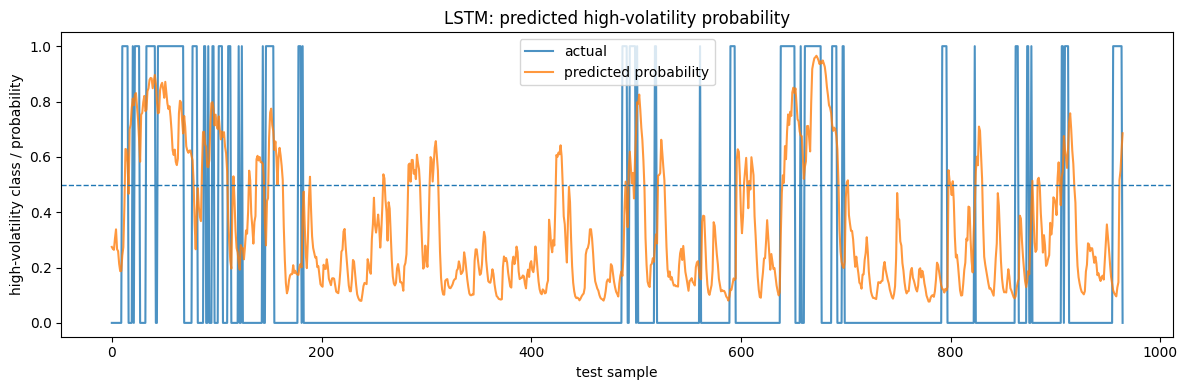

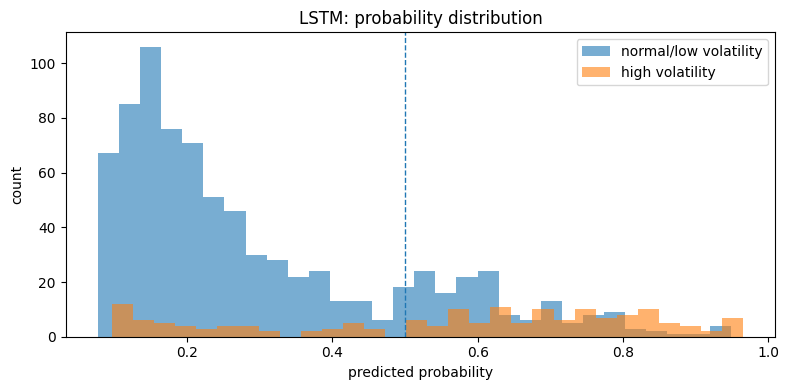


CNN
Epoch 01 | train=0.7639 | val=0.9409
Epoch 02 | train=0.6869 | val=0.9375
Epoch 03 | train=0.6506 | val=0.9454
Epoch 04 | train=0.6166 | val=0.9974
Epoch 05 | train=0.5991 | val=0.8842
Epoch 06 | train=0.5892 | val=1.1391
Epoch 07 | train=0.5692 | val=0.9269
Epoch 08 | train=0.5462 | val=1.1738
Epoch 09 | train=0.5379 | val=1.0198
Epoch 10 | train=0.5227 | val=1.0403
threshold: 0.405
validation balanced accuracy: 0.730
test balanced accuracy: 0.664
[[583 219]
 [ 65  98]]


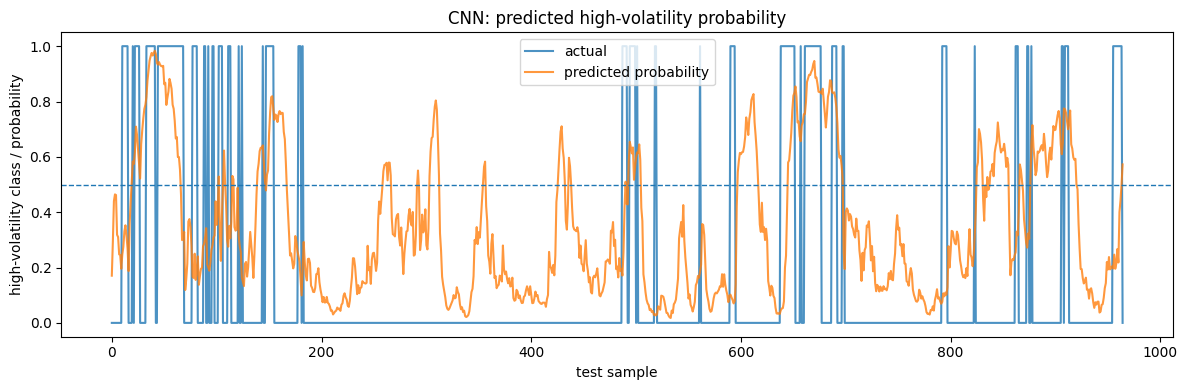

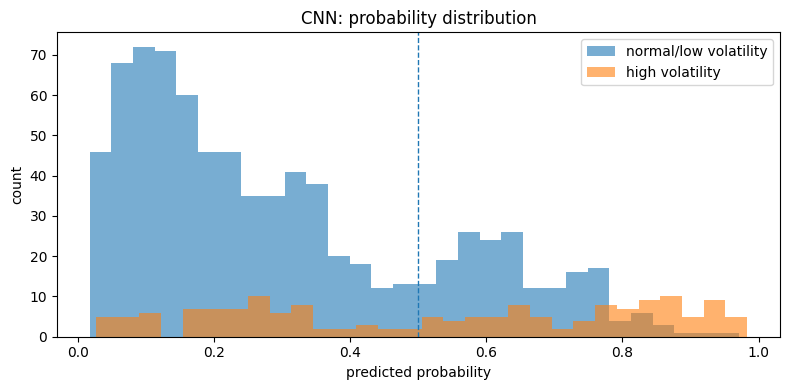


Transformer
Epoch 01 | train=0.7313 | val=0.8393
Epoch 02 | train=0.7272 | val=0.7972
Epoch 03 | train=0.6441 | val=0.8266
Epoch 04 | train=0.6666 | val=0.9131
Epoch 05 | train=0.6244 | val=0.9363
Epoch 06 | train=0.6210 | val=0.9321
Epoch 07 | train=0.5956 | val=0.8777
threshold: 0.480
validation balanced accuracy: 0.762
test balanced accuracy: 0.746
[[636 166]
 [ 49 114]]


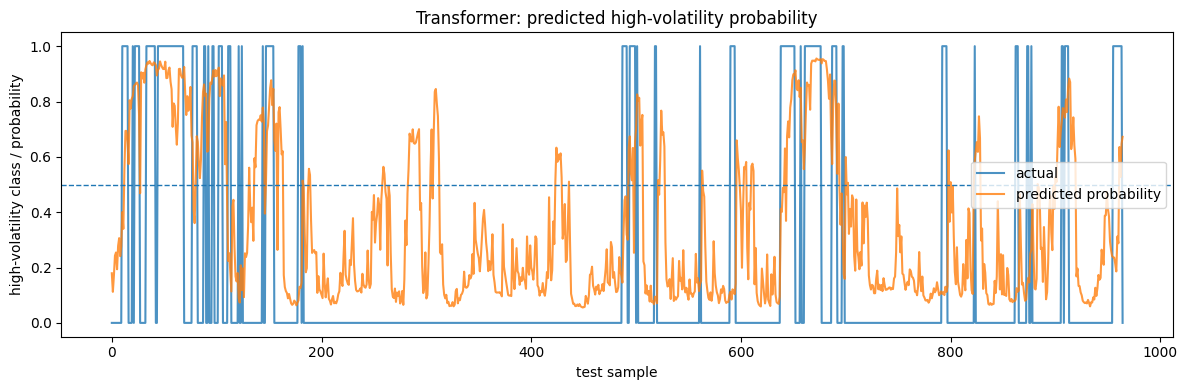

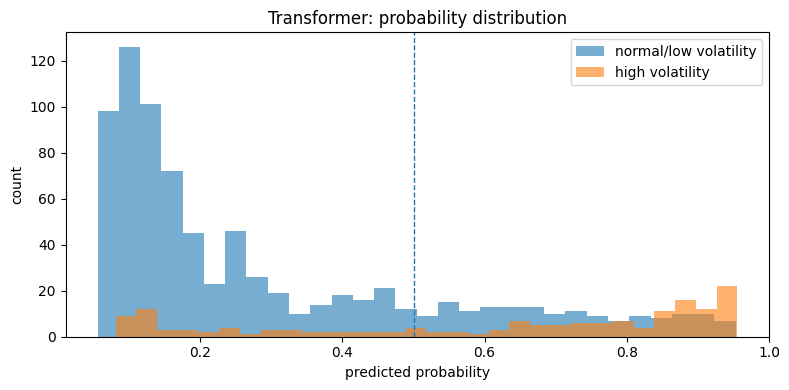

,model,threshold,validation_balanced_accuracy,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,LSTM,0.525,0.770050,0.804145,0.740415,0.444915,0.644172,0.526316,0.780526
1,CNN,0.405,0.730168,0.705699,0.664080,0.309148,0.601227,0.408333,0.730635
2,Transformer,0.480,0.762191,0.777202,0.746202,0.407143,0.699387,0.514673,0.798533


In [11]:
models = {
    "LSTM": LSTMModel(len(FEATURES)),
    "CNN": CNN1DModel(len(FEATURES)),
    "Transformer": TransformerModel(len(FEATURES)),
}

trained_models = {}
results = {}

for name, model in models.items():
    print(f"\n{name}")
    trained = train_model(model, train_loader, val_loader, cfg)
    trained_models[name] = trained

    val_probs, val_labels = predict_proba(trained, val_loader)
    threshold = tune_threshold(val_labels, val_probs)

    val_metrics = evaluate_model(trained, val_loader, threshold)
    test_metrics = evaluate_model(trained, test_loader, threshold)

    results[name] = {
        **test_metrics,
        "validation_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    print(f"threshold: {threshold:.3f}")
    print(
        "validation balanced accuracy: "
        f"{val_metrics['balanced_accuracy']:.3f}"
    )
    print(
        "test balanced accuracy: "
        f"{test_metrics['balanced_accuracy']:.3f}"
    )
    print(test_metrics["confusion_matrix"])

    plot_probability_series(
        test_metrics["labels"],
        test_metrics["probs"],
        f"{name}: predicted high-volatility probability",
        output_dir / f"{name}_probability_series.png",
    )

    plot_probability_histogram(
        test_metrics["labels"],
        test_metrics["probs"],
        f"{name}: probability distribution",
        output_dir / f"{name}_probability_histogram.png",
    )

summary = pd.DataFrame([
    {
        "model": name,
        "threshold": m["threshold"],
        "validation_balanced_accuracy": m[
            "validation_balanced_accuracy"
        ],
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
    }
    for name, m in results.items()
])

summary.to_csv(output_dir / "model_results.csv", index=False)
summary


## 8. Logistic-regression baseline

The baseline receives the same standardized 30-day sequences as the neural models after flattening each sequence into 330 predictors. Its classification threshold is selected using validation balanced accuracy. It is included only for predictive comparison and is not part of the XAI analysis.


In [12]:
# Logistic-regression baseline using the same 30-day sequences.

x_train_lr, y_train_lr = dataset_to_numpy(train_ds)
x_val_lr, y_val_lr = dataset_to_numpy(val_ds)
x_test_lr, y_test_lr = dataset_to_numpy(test_ds)

# Flatten each 30 x 11 sequence into 330 predictors.
x_train_lr = x_train_lr.reshape(len(x_train_lr), -1)
x_val_lr = x_val_lr.reshape(len(x_val_lr), -1)
x_test_lr = x_test_lr.reshape(len(x_test_lr), -1)

logistic_baseline = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    solver="lbfgs",
    random_state=cfg.seed,
)

logistic_baseline.fit(x_train_lr, y_train_lr.astype(int))

val_probs_lr = logistic_baseline.predict_proba(x_val_lr)[:, 1]
test_probs_lr = logistic_baseline.predict_proba(x_test_lr)[:, 1]

# Select the decision threshold using validation data only.
threshold_lr = tune_threshold(
    y_val_lr.astype(int),
    val_probs_lr,
)

test_preds_lr = (test_probs_lr >= threshold_lr).astype(int)

logistic_results = {
    "model": "Logistic regression",
    "threshold": threshold_lr,
    "validation_balanced_accuracy": balanced_accuracy_score(
        y_val_lr,
        (val_probs_lr >= threshold_lr).astype(int),
    ),
    "accuracy": accuracy_score(y_test_lr, test_preds_lr),
    "balanced_accuracy": balanced_accuracy_score(
        y_test_lr,
        test_preds_lr,
    ),
    "precision": precision_score(
        y_test_lr,
        test_preds_lr,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test_lr,
        test_preds_lr,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test_lr,
        test_preds_lr,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test_lr,
        test_probs_lr,
    ),
}

summary_with_baseline = pd.concat(
    [
        pd.DataFrame([logistic_results]),
        summary,
    ],
    ignore_index=True,
)

summary_with_baseline.to_csv(
    output_dir / "model_results_with_baseline.csv",
    index=False,
)

print("Logistic-regression confusion matrix:")
print(confusion_matrix(y_test_lr, test_preds_lr))

summary_with_baseline

Logistic-regression confusion matrix:
[[579 223]
 [ 59 104]]


,model,threshold,validation_balanced_accuracy,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.300,0.716609,0.707772,0.679991,0.318043,0.638037,0.424490,0.737910
1,LSTM,0.525,0.770050,0.804145,0.740415,0.444915,0.644172,0.526316,0.780526
2,CNN,0.405,0.730168,0.705699,0.664080,0.309148,0.601227,0.408333,0.730635
3,Transformer,0.480,0.762191,0.777202,0.746202,0.407143,0.699387,0.514673,0.798533


## 9. Multivariate explanations

The multivariate models are explained in probability space using a zero baseline in standardized feature space.

For the temporal explanation, adjacent observations are grouped into fixed, non-overlapping subsequences. Each subsequence becomes one interpretable binary feature. KernelSHAP is then fitted over coalitions of subsequences, so neighboring dependent time points receive a joint contribution instead of many isolated point-level scores.

The visualization mirrors the WindowSHAP lecture example: the black line represents the observed standardized sequence, red bars indicate subsequences that increase the predicted high-volatility probability, and blue bars indicate subsequences that decrease it.


In [13]:
def financial_concept_indices(feature_names: list[str]) -> dict[str, list[int]]:
    """Return non-overlapping financial feature groups.

    Non-overlapping groups are important because sampled Shapley efficiency is
    otherwise violated when the same feature is counted in multiple concepts.
    """
    index = {name: i for i, name in enumerate(feature_names)}
    groups = {
        "returns": ["log_return", "abs_return", "squared_return"],
        "volatility": ["volatility_5", "volatility_20"],
        "price_range": ["high_low_range", "open_close_range"],
        "momentum": ["sma_5_gap", "sma_20_gap", "rsi_14"],
        "volume": ["volume_change"],
    }
    return {
        concept: [index[col] for col in cols if col in index]
        for concept, cols in groups.items()
    }


def concept_masks(
    x: torch.Tensor,
    feature_names: list[str],
) -> dict[str, torch.Tensor]:
    """Create masks containing only the values belonging to each concept."""
    concepts = {}
    for concept, indices in financial_concept_indices(feature_names).items():
        tensor = torch.zeros_like(x)
        tensor[:, :, indices] = x[:, :, indices]
        concepts[concept] = tensor
    return concepts


def sampled_concept_shap(
    model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    concepts: dict[str, torch.Tensor],
    n_permutations: int,
) -> dict[str, float]:
    """Approximate concept-level Shapley values using random permutations.

    The model must return the output that is being explained. In this notebook,
    the multivariate methods explain the high-volatility probability.
    """
    model.eval()
    x = x.to(device)
    baseline = baseline.to(device)
    concept_tensors = {k: v.to(device) for k, v in concepts.items()}

    names = list(concept_tensors)
    values = {name: 0.0 for name in names}

    with torch.no_grad():
        for _ in range(n_permutations):
            order = np.random.permutation(len(names))
            current = baseline.clone()
            previous = float(model(current).item())

            for idx in order:
                name = names[idx]
                current = current + concept_tensors[name]
                new = float(model(current).item())
                values[name] += new - previous
                previous = new

    return {name: value / n_permutations for name, value in values.items()}


def windowshap_subsequences(
    model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    window_size: int,
    nsamples: int = 200,
    random_state: int = 42,
):
    """Fixed-window WindowSHAP using KernelSHAP over temporal subsequences."""
    from sklearn.linear_model import LinearRegression
    from math import comb

    model.eval()
    x = x.to(device)
    baseline = baseline.to(device)

    lookback = x.shape[1]
    windows = [
        (start, min(start + window_size, lookback))
        for start in range(0, lookback, window_size)
    ]
    n_windows = len(windows)

    rng = np.random.default_rng(random_state)
    coalitions = [
        np.zeros(n_windows, dtype=int),
        np.ones(n_windows, dtype=int),
    ]
    seen = {tuple(coalitions[0]), tuple(coalitions[1])}

    max_unique = 2 ** n_windows
    target = min(max(nsamples, 2), max_unique)

    while len(coalitions) < target:
        coalition = rng.integers(0, 2, size=n_windows, dtype=int)
        key = tuple(coalition.tolist())
        if key not in seen:
            seen.add(key)
            coalitions.append(coalition)

    coalition_matrix = np.asarray(coalitions, dtype=float)

    def build_input(mask: np.ndarray) -> torch.Tensor:
        masked = baseline.clone()
        for enabled, (start, end) in zip(mask.astype(bool), windows):
            if enabled:
                masked[:, start:end, :] = x[:, start:end, :]
        return masked

    outputs = []
    with torch.no_grad():
        for mask in coalition_matrix:
            outputs.append(float(model(build_input(mask)).item()))
    outputs = np.asarray(outputs, dtype=float)

    def kernel_weight(mask: np.ndarray) -> float:
        coalition_size = int(mask.sum())
        if coalition_size == 0 or coalition_size == n_windows:
            return 1e6
        return (n_windows - 1) / (
            comb(n_windows, coalition_size)
            * coalition_size
            * (n_windows - coalition_size)
        )

    weights = np.asarray(
        [kernel_weight(mask) for mask in coalition_matrix],
        dtype=float,
    )

    surrogate = LinearRegression()
    surrogate.fit(
        coalition_matrix,
        outputs,
        sample_weight=weights,
    )

    shap_values = surrogate.coef_.astype(float)
    expected_value = float(surrogate.intercept_)

    with torch.no_grad():
        observed_value = float(model(x).item())

    # Enforce local accuracy for the displayed explanation.
    residual = observed_value - expected_value - shap_values.sum()
    shap_values += residual / n_windows

    return windows, shap_values, expected_value, observed_value


def plot_windowshap_subsequences(
    x: torch.Tensor,
    windows: list[tuple[int, int]],
    shap_values: np.ndarray,
    title: str,
    save_path: Path | None = None,
):
    """Plot observed data with positive and negative subsequence Shapley values."""
    observed = x.squeeze(0).detach().cpu().numpy()

    # The input is standardized, so averaging across channels gives a compact
    # observed-series overview comparable to the lecture illustration.
    observed_line = observed.mean(axis=1)

    timestep_values = np.zeros(len(observed_line), dtype=float)
    for value, (start, end) in zip(shap_values, windows):
        timestep_values[start:end] = value / max(end - start, 1)

    positive = np.clip(timestep_values, 0, None)
    negative = np.clip(timestep_values, None, 0)
    time = np.arange(len(observed_line))

    fig, ax_shap = plt.subplots(figsize=(12, 5))
    ax_data = ax_shap.twinx()

    neg_bars = ax_shap.bar(
        time,
        negative,
        width=0.9,
        color="blue",
        label="Negative Shapley values",
    )
    pos_bars = ax_shap.bar(
        time,
        positive,
        width=0.9,
        color="red",
        label="Positive Shapley values",
    )
    data_line, = ax_data.plot(
        time,
        observed_line,
        color="black",
        linewidth=1.7,
        label="Observed data",
    )

    for start, _ in windows[1:]:
        ax_shap.axvline(
            start - 0.5,
            color="grey",
            linewidth=0.7,
            alpha=0.45,
        )

    ax_shap.axhline(0, color="black", linewidth=0.8)
    ax_shap.set_xlabel("Time steps")
    ax_shap.set_ylabel("Shapley values")
    ax_data.set_ylabel("Observed standardized data")
    ax_shap.set_title(title)
    ax_shap.legend(
        [neg_bars, pos_bars, data_line],
        [
            "Negative Shapley values",
            "Positive Shapley values",
            "Observed data",
        ],
        loc="upper right",
    )

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def sampled_window_shap(
    model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    window_size: int,
    n_permutations: int,
):
    """Compatibility wrapper used by the objective-evaluation section."""
    windows, values, _, _ = windowshap_subsequences(
        model=model,
        x=x,
        baseline=baseline,
        window_size=window_size,
        nsamples=n_permutations,
    )
    return windows, values

def integrated_gradients(
    model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    n_steps: int = 100,
):
    """Calculate Integrated Gradients in the model's output space."""
    was_training = model.training
    model = model.to(device)
    model.eval()

    x = x.to(device)
    baseline = baseline.to(device)
    ig = IntegratedGradients(model)

    with torch.backends.cudnn.flags(enabled=False):
        attr, delta = ig.attribute(
            x,
            baselines=baseline,
            n_steps=n_steps,
            return_convergence_delta=True,
        )

    if was_training:
        model.train()

    return attr.squeeze(0).detach().cpu().numpy(), float(delta.item())


# Backwards-compatible aliases used in the visualisation cell.
concept_shap = sampled_concept_shap
window_shap = sampled_window_shap
financial_concepts = concept_masks


selected model: LSTM
selection criterion: validation balanced accuracy
selected positive sample: 672
actual: 1
probability: 0.9653012752532959


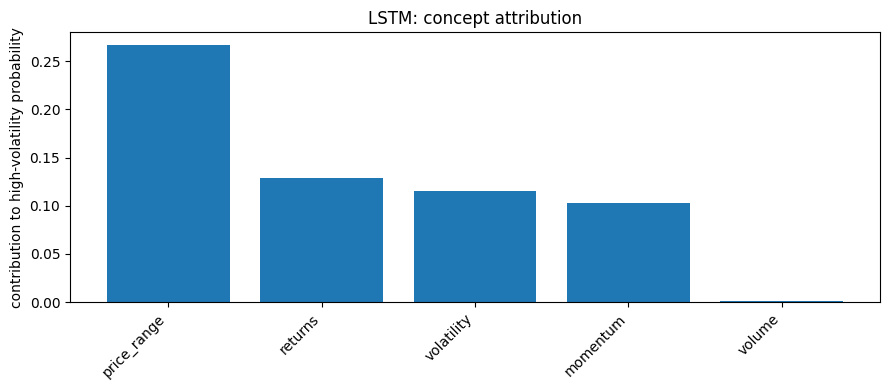

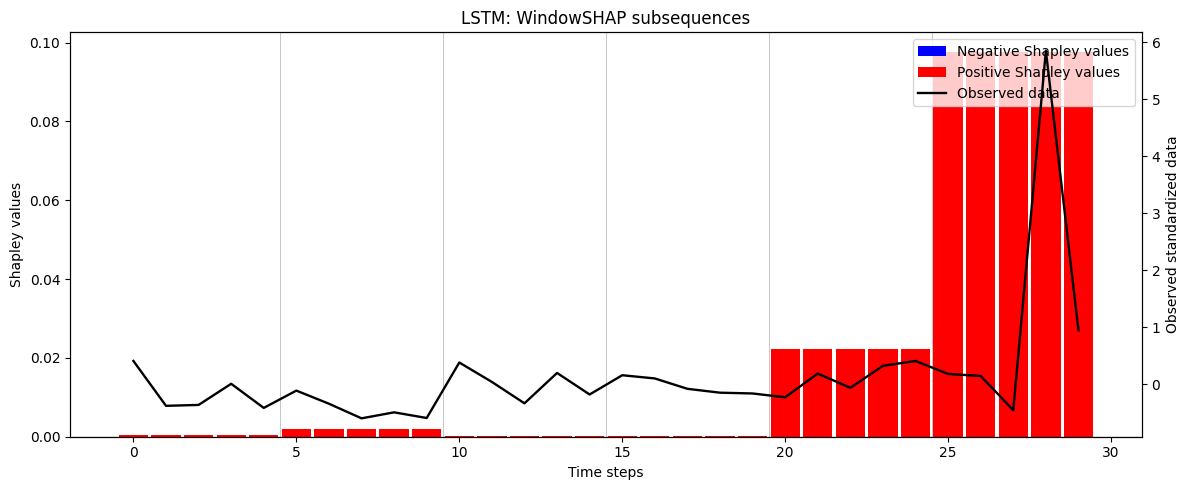

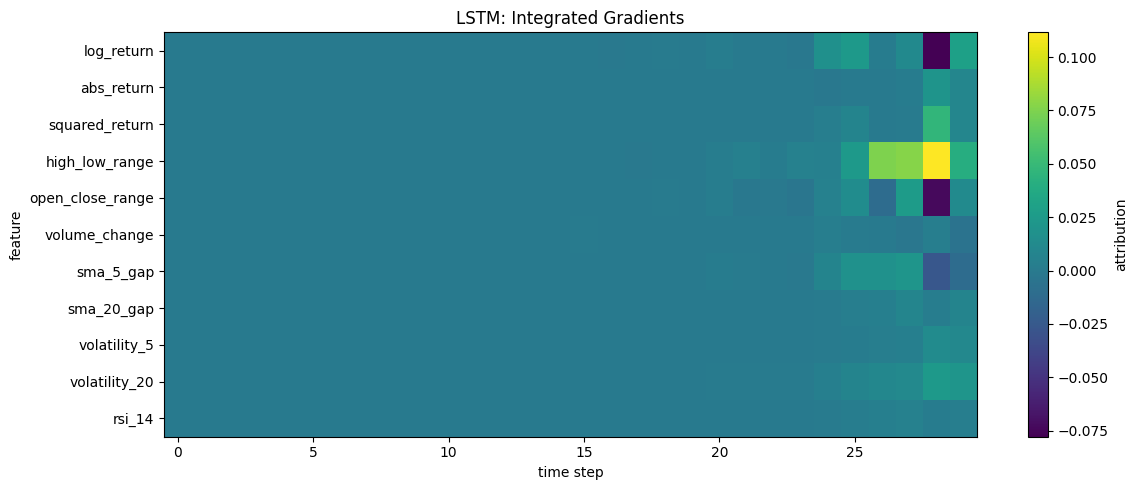

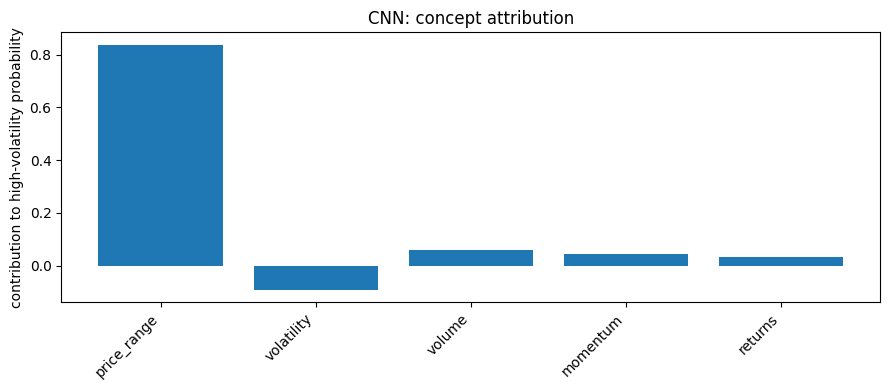

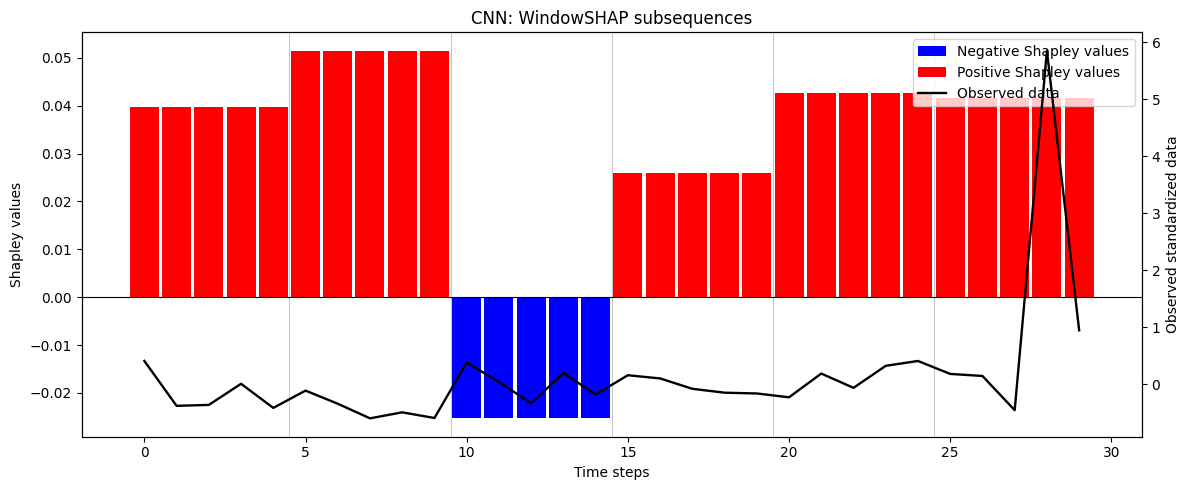

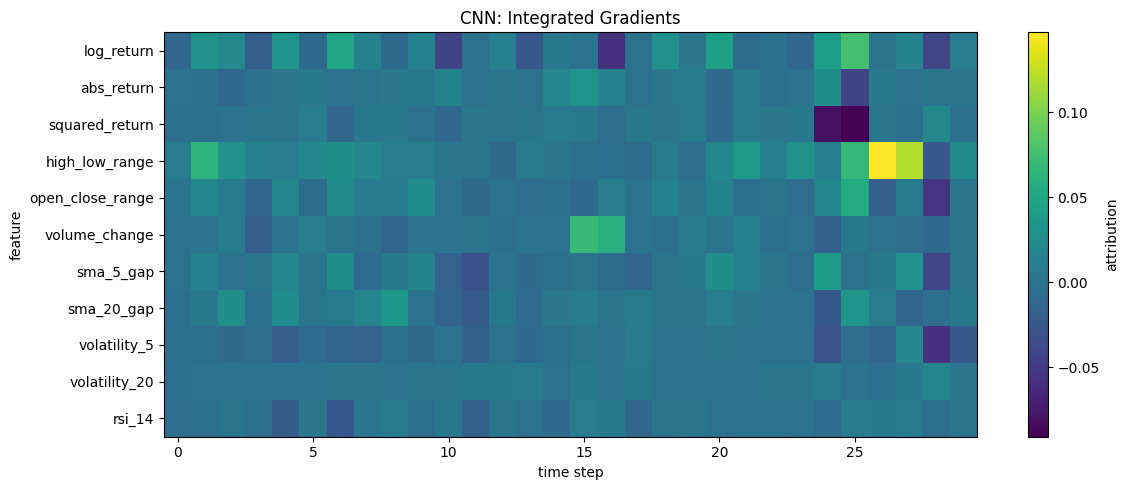

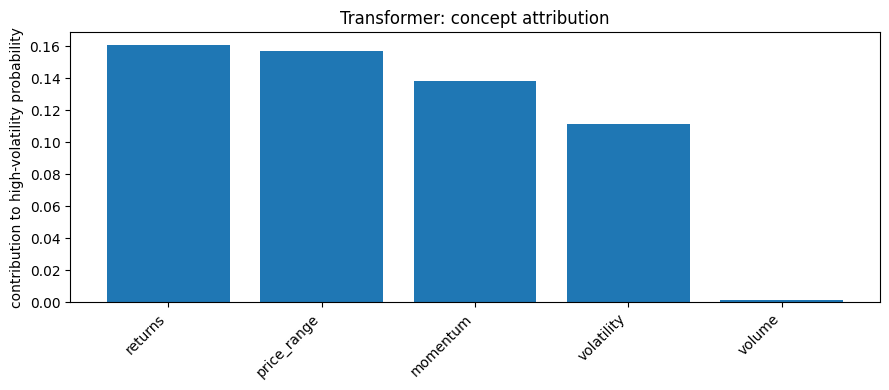

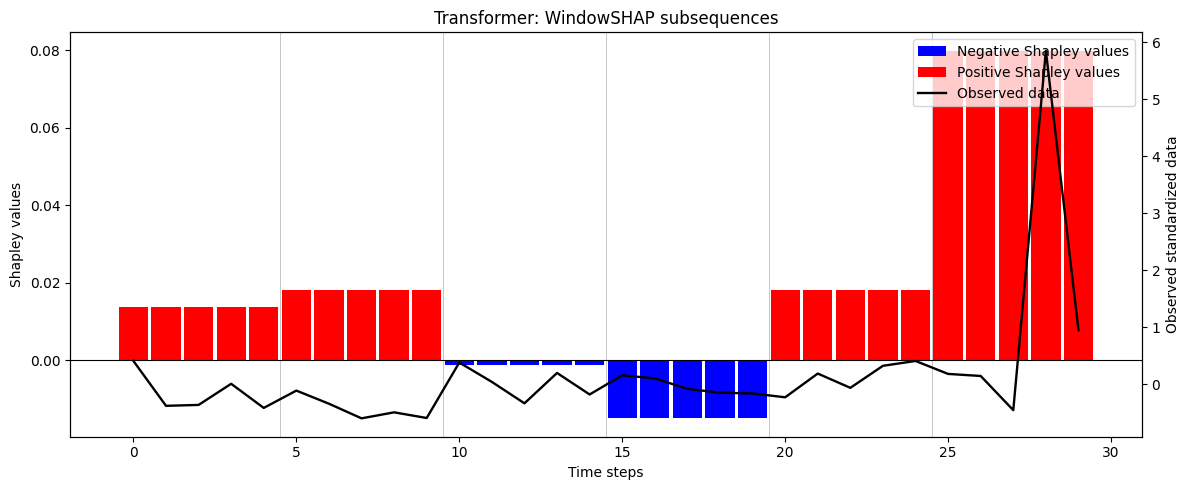

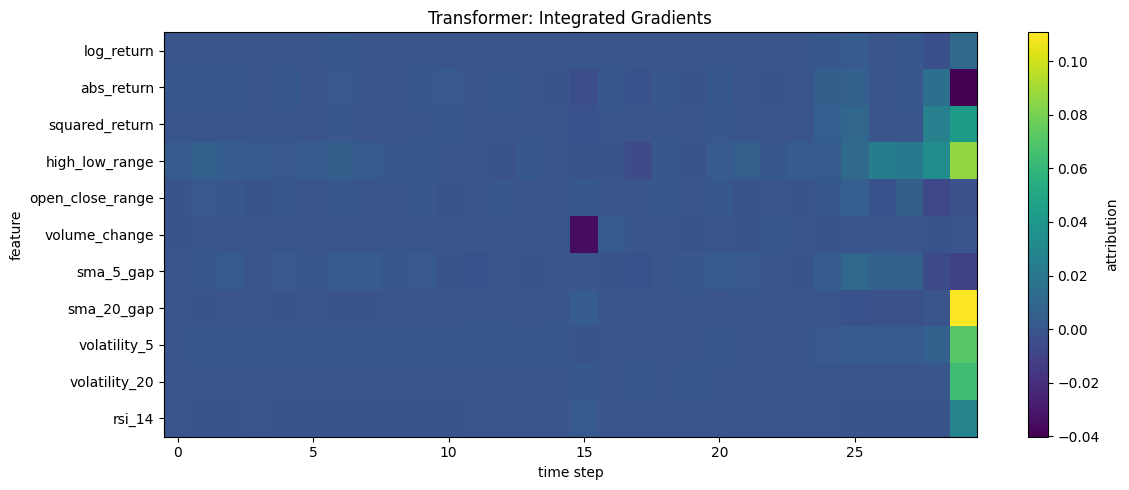

In [14]:
# Select the explanation model using validation balanced accuracy.
best_model_name = summary.sort_values(
    "validation_balanced_accuracy",
    ascending=False,
).iloc[0]["model"]
best_model = trained_models[best_model_name]

test_probs, test_labels = predict_proba(best_model, test_loader)
best_threshold = float(results[best_model_name]["threshold"])
test_predictions = (test_probs >= best_threshold).astype(int)

# Select the highest-confidence true-positive case for the positive example.
true_positive_candidates = np.where(
    (test_labels.astype(int) == 1) & (test_predictions == 1)
)[0]
if len(true_positive_candidates) == 0:
    raise RuntimeError(
        "No true-positive observation was found for the selected model."
    )

sample_idx = int(
    true_positive_candidates[
        np.argmax(test_probs[true_positive_candidates])
    ]
)

x_instance, y_instance = test_ds[sample_idx]
x_instance = x_instance.unsqueeze(0)
baseline = torch.zeros_like(x_instance)

print("selected model:", best_model_name)
print("selection criterion: validation balanced accuracy")
print("selected positive sample:", sample_idx)
print("actual:", int(y_instance.item()))
print("probability:", float(test_probs[sample_idx]))

for name, model in trained_models.items():
    prob_model = ProbabilityModel(model).to(device)

    concept_values = concept_shap(
        prob_model,
        x_instance,
        baseline,
        financial_concepts(x_instance, FEATURES),
        cfg.shap_samples,
    )

    pd.DataFrame({
        "concept": list(concept_values.keys()),
        "attribution": list(concept_values.values()),
    }).to_csv(output_dir / f"{name}_concept_shap.csv", index=False)

    plot_bar(
        concept_values,
        f"{name}: concept attribution",
        "contribution to high-volatility probability",
        output_dir / f"{name}_concept_shap.png",
    )

    windows, win_values, expected_value, observed_value = windowshap_subsequences(
        prob_model,
        x_instance,
        baseline,
        cfg.window_size,
        nsamples=cfg.shap_samples,
    )

    pd.DataFrame({
        "window_start": [start for start, _ in windows],
        "window_end": [end for _, end in windows],
        "shap_value": win_values,
        "expected_value": expected_value,
        "observed_value": observed_value,
    }).to_csv(
        output_dir / f"{name}_windowshap_subsequences.csv",
        index=False,
    )

    plot_windowshap_subsequences(
        x=x_instance,
        windows=windows,
        shap_values=win_values,
        title=f"{name}: WindowSHAP subsequences",
        save_path=output_dir / f"{name}_windowshap_subsequences.png",
    )

    ig_values, delta = integrated_gradients(prob_model, x_instance, baseline)
    pd.DataFrame(
        ig_values,
        columns=FEATURES,
    ).to_csv(
        output_dir / f"{name}_integrated_gradients.csv",
        index=False,
    )

    plot_heatmap(
        ig_values,
        FEATURES,
        f"{name}: Integrated Gradients",
        output_dir / f"{name}_integrated_gradients.png",
    )

    pd.DataFrame({
        "model": [name],
        "integrated_gradients_convergence_delta": [delta],
    }).to_csv(
        output_dir / f"{name}_integrated_gradients_diagnostics.csv",
        index=False,
    )


### Contrasting negative-attribution example

To avoid presenting only evidence in favour of a high-volatility prediction, the following cell also explains a confident true-negative prediction from the best-performing model. The positive and negative examples can be compared in the report to show which features, financial concepts, and temporal windows increase or decrease the predicted probability of high volatility.


negative example model: LSTM
negative example sample: 779
actual: 0
probability: 0.07699230313301086


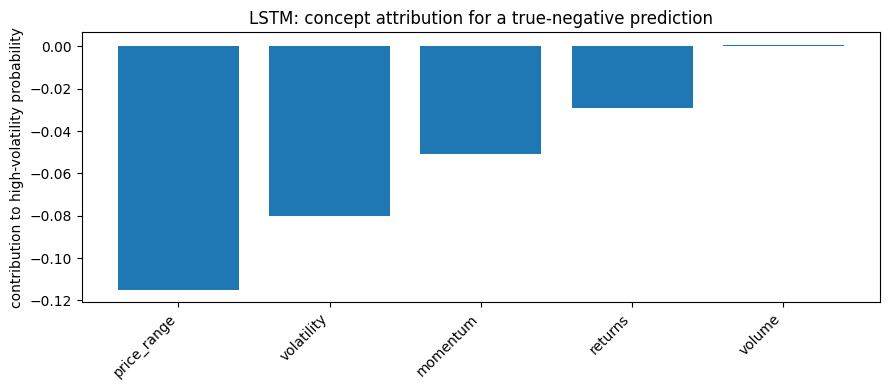

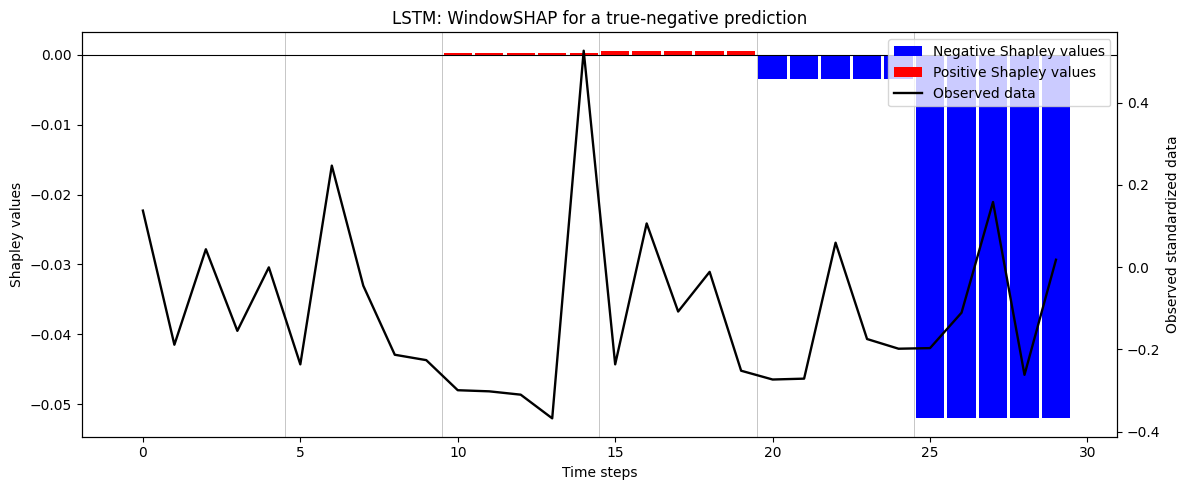

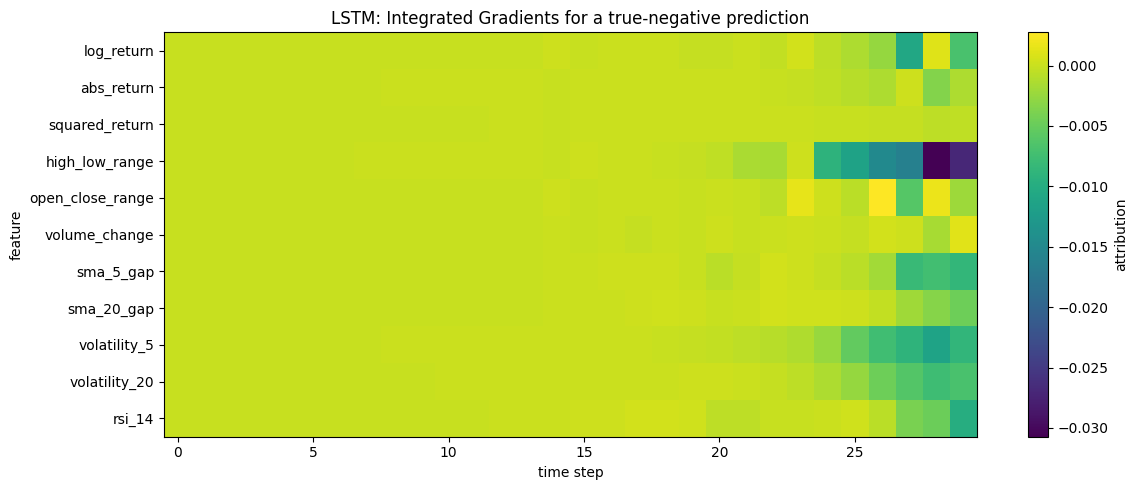

In [15]:
# Select a confident true-negative observation for a contrasting explanation.
test_targets = np.array([int(test_ds[i][1].item()) for i in range(len(test_ds))])
true_negative_candidates = np.where(test_targets == 0)[0]

if len(true_negative_candidates) == 0:
    raise RuntimeError("No negative-class observations were found in the test set.")

negative_sample_idx = int(
    true_negative_candidates[
        np.argmin(test_probs[true_negative_candidates])
    ]
)

x_negative, y_negative = test_ds[negative_sample_idx]
x_negative = x_negative.unsqueeze(0)
negative_baseline = torch.zeros_like(x_negative)

negative_prob_model = ProbabilityModel(best_model).to(device)
negative_prob_model.eval()

print("negative example model:", best_model_name)
print("negative example sample:", negative_sample_idx)
print("actual:", int(y_negative.item()))
print("probability:", float(test_probs[negative_sample_idx]))

# Financial concept attribution.
negative_concept_values = concept_shap(
    negative_prob_model,
    x_negative,
    negative_baseline,
    financial_concepts(x_negative, FEATURES),
    cfg.shap_samples,
)

pd.DataFrame({
    "concept": list(negative_concept_values.keys()),
    "attribution": list(negative_concept_values.values()),
}).to_csv(
    output_dir / f"{best_model_name}_negative_concept_shap.csv",
    index=False,
)

plot_bar(
    negative_concept_values,
    f"{best_model_name}: concept attribution for a true-negative prediction",
    "contribution to high-volatility probability",
    output_dir / f"{best_model_name}_negative_concept_shap.png",
)

# Fixed-window WindowSHAP.
negative_windows, negative_window_values, negative_expected, negative_observed = (
    windowshap_subsequences(
        negative_prob_model,
        x_negative,
        negative_baseline,
        cfg.window_size,
        nsamples=cfg.shap_samples,
    )
)

pd.DataFrame({
    "window_start": [start for start, _ in negative_windows],
    "window_end": [end for _, end in negative_windows],
    "shap_value": negative_window_values,
    "expected_value": negative_expected,
    "observed_value": negative_observed,
}).to_csv(
    output_dir / f"{best_model_name}_negative_windowshap_subsequences.csv",
    index=False,
)

plot_windowshap_subsequences(
    x=x_negative,
    windows=negative_windows,
    shap_values=negative_window_values,
    title=f"{best_model_name}: WindowSHAP for a true-negative prediction",
    save_path=output_dir / f"{best_model_name}_negative_windowshap_subsequences.png",
)

# Integrated Gradients.
negative_ig_values, negative_ig_delta = integrated_gradients(
    negative_prob_model,
    x_negative,
    negative_baseline,
)

pd.DataFrame(
    negative_ig_values,
    columns=FEATURES,
).to_csv(
    output_dir / f"{best_model_name}_negative_integrated_gradients.csv",
    index=False,
)

plot_heatmap(
    negative_ig_values,
    FEATURES,
    f"{best_model_name}: Integrated Gradients for a true-negative prediction",
    output_dir / f"{best_model_name}_negative_integrated_gradients.png",
)

pd.DataFrame({
    "model": [best_model_name],
    "sample_idx": [negative_sample_idx],
    "target": [int(y_negative.item())],
    "predicted_probability": [float(test_probs[negative_sample_idx])],
    "integrated_gradients_convergence_delta": [negative_ig_delta],
}).to_csv(
    output_dir / f"{best_model_name}_negative_explanation_summary.csv",
    index=False,
)


### WindowSHAP implementation note

This is the **fixed-window** WindowSHAP variant: subsequences are predefined using a constant window size and explained with KernelSHAP. It captures the main WindowSHAP principle shown in the course material, but it does not implement the dynamic-window or adaptive-window search strategies from the full paper.


## 10. Objective evaluation of explanations

Visual inspection alone is insufficient for evaluating XAI methods. The following diagnostics are therefore calculated for the best-performing multivariate model:

1. **Completeness:** whether attribution sums reconstruct the difference between the observed prediction and the baseline prediction.
2. **Deletion faithfulness:** how quickly the prediction changes when the most important input groups are replaced by the baseline.
3. **Stability:** whether small input perturbations produce similar Integrated Gradients rankings.
4. **Cross-method agreement:** whether Integrated Gradients and fixed-window WindowSHAP attribution rank temporal windows similarly.

These criteria do not prove that an explanation is causally correct, but they provide reproducible and objective evidence about internal consistency and model faithfulness.


In [16]:
def probability(model: nn.Module, x: torch.Tensor) -> float:
    model.eval()
    with torch.no_grad():
        return float(torch.sigmoid(model(x.to(device))).item())


def safe_spearman(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman rank correlation without an additional SciPy dependency."""
    a = pd.Series(np.asarray(a).ravel())
    b = pd.Series(np.asarray(b).ravel())
    if a.nunique() <= 1 or b.nunique() <= 1:
        return np.nan
    return float(a.corr(b, method="spearman"))


def aggregate_ig_by_window(
    ig_values: np.ndarray,
    windows: list[tuple[int, int]],
) -> np.ndarray:
    point_importance = np.abs(ig_values).sum(axis=1)
    return np.array([
        point_importance[start:end].sum()
        for start, end in windows
    ])


def completeness_diagnostics(
    prob_model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    ig_values: np.ndarray,
    concept_values: dict[str, float],
    window_values: np.ndarray,
) -> dict[str, float]:
    with torch.no_grad():
        observed = float(prob_model(x.to(device)).item())
        base = float(prob_model(baseline.to(device)).item())

    target_difference = observed - base
    return {
        "prediction_probability": observed,
        "baseline_probability": base,
        "prediction_minus_baseline": target_difference,
        "ig_sum": float(ig_values.sum()),
        "ig_absolute_residual": abs(target_difference - float(ig_values.sum())),
        "concept_sum": float(sum(concept_values.values())),
        "concept_absolute_residual": abs(
            target_difference - float(sum(concept_values.values()))
        ),
        "window_sum": float(np.sum(window_values)),
        "window_absolute_residual": abs(
            target_difference - float(np.sum(window_values))
        ),
    }


def deletion_curve_for_cells(
    prob_model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    attribution: np.ndarray,
    target_class: int,
    steps: int = 10,
) -> pd.DataFrame:
    """Mask important cells and track the selected class score."""
    importance = np.abs(attribution)
    ranking = np.argsort(importance.ravel())[::-1]
    total = len(ranking)

    rows = []
    for step in range(steps + 1):
        fraction = step / steps
        n_mask = int(round(fraction * total))
        modified = x.clone()

        if n_mask > 0:
            flat_indices = ranking[:n_mask]
            time_idx, feature_idx = np.unravel_index(
                flat_indices,
                importance.shape,
            )
            modified[0, time_idx, feature_idx] = baseline[
                0, time_idx, feature_idx
            ]

        with torch.no_grad():
            prob = float(prob_model(modified.to(device)).item())

        class_score = prob if target_class == 1 else 1.0 - prob
        rows.append({
            "fraction_masked": fraction,
            "high_volatility_probability": prob,
            "target_class": int(target_class),
            "target_class_score": class_score,
        })

    return pd.DataFrame(rows)


def deletion_curve_for_windows(
    prob_model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    windows: list[tuple[int, int]],
    values: np.ndarray,
    target_class: int,
) -> pd.DataFrame:
    """Mask windows and track the selected class score."""
    order = np.argsort(np.abs(values))[::-1]
    modified = x.clone()
    rows = []

    with torch.no_grad():
        prob = float(prob_model(modified.to(device)).item())
        class_score = prob if target_class == 1 else 1.0 - prob
        rows.append({
            "windows_masked": 0,
            "fraction_masked": 0.0,
            "high_volatility_probability": prob,
            "target_class": int(target_class),
            "target_class_score": class_score,
        })

    for rank, idx in enumerate(order, start=1):
        start, end = windows[idx]
        modified[:, start:end, :] = baseline[:, start:end, :]

        with torch.no_grad():
            prob = float(prob_model(modified.to(device)).item())

        class_score = prob if target_class == 1 else 1.0 - prob
        rows.append({
            "windows_masked": rank,
            "fraction_masked": rank / len(windows),
            "high_volatility_probability": prob,
            "target_class": int(target_class),
            "target_class_score": class_score,
        })

    return pd.DataFrame(rows)


def deletion_auc(curve: pd.DataFrame) -> float:
    """Area under the predicted-class deletion curve.

    Lower values indicate that masking highly ranked inputs removes evidence for
    the originally predicted class more rapidly.
    """
    return float(np.trapz(
        curve["target_class_score"],
        curve["fraction_masked"],
    ))


def ig_stability(
    prob_model: nn.Module,
    x: torch.Tensor,
    baseline: torch.Tensor,
    reference_ig: np.ndarray,
    repeats: int,
    noise_std: float,
) -> dict[str, float]:
    reference_feature = np.abs(reference_ig).sum(axis=0)
    correlations = []

    for _ in range(repeats):
        noisy_x = x + torch.randn_like(x) * noise_std
        noisy_ig, _ = integrated_gradients(
            prob_model,
            noisy_x,
            baseline,
            n_steps=50,
        )
        noisy_feature = np.abs(noisy_ig).sum(axis=0)
        correlations.append(
            safe_spearman(reference_feature, noisy_feature)
        )

    valid = np.array([x for x in correlations if not np.isnan(x)])
    return {
        "mean_spearman": float(valid.mean()) if len(valid) else np.nan,
        "std_spearman": float(valid.std()) if len(valid) else np.nan,
        "minimum_spearman": float(valid.min()) if len(valid) else np.nan,
    }


In [17]:
# Evaluate explanations on a deterministic subset of test observations.
evaluation_model_name = summary.sort_values(
    "validation_balanced_accuracy",
    ascending=False,
).iloc[0]["model"]
evaluation_model = trained_models[evaluation_model_name]
evaluation_prob_model = ProbabilityModel(evaluation_model).to(device)
evaluation_prob_model.eval()
evaluation_threshold = float(results[evaluation_model_name]["threshold"])

n_eval = min(cfg.xai_eval_samples, len(test_ds))
evaluation_indices = np.linspace(
    0,
    len(test_ds) - 1,
    n_eval,
    dtype=int,
)

diagnostic_rows = []
agreement_rows = []
deletion_rows = []

for eval_sample_idx in evaluation_indices:
    x_eval, y_eval = test_ds[int(eval_sample_idx)]
    x_eval = x_eval.unsqueeze(0)
    baseline_eval = torch.zeros_like(x_eval)

    with torch.no_grad():
        original_probability = float(
            evaluation_prob_model(x_eval.to(device)).item()
        )
    predicted_class = int(
        original_probability >= evaluation_threshold
    )

    concepts_eval = financial_concepts(x_eval, FEATURES)

    concept_values_eval = concept_shap(
        evaluation_prob_model,
        x_eval,
        baseline_eval,
        concepts_eval,
        cfg.xai_eval_permutations,
    )

    windows_eval, window_values_eval = window_shap(
        evaluation_prob_model,
        x_eval,
        baseline_eval,
        cfg.window_size,
        cfg.xai_eval_permutations,
    )

    ig_eval, ig_delta_eval = integrated_gradients(
        evaluation_prob_model,
        x_eval,
        baseline_eval,
        n_steps=100,
    )

    diagnostics = completeness_diagnostics(
        evaluation_prob_model,
        x_eval,
        baseline_eval,
        ig_eval,
        concept_values_eval,
        window_values_eval,
    )
    diagnostics.update({
        "model": evaluation_model_name,
        "sample_idx": int(eval_sample_idx),
        "target": int(y_eval.item()),
        "predicted_class": predicted_class,
        "ig_convergence_delta": ig_delta_eval,
    })
    diagnostic_rows.append(diagnostics)

    ig_window_importance = aggregate_ig_by_window(
        ig_eval,
        windows_eval,
    )
    agreement_rows.append({
        "model": evaluation_model_name,
        "sample_idx": int(eval_sample_idx),
        "ig_window_vs_window_shap_spearman": safe_spearman(
            ig_window_importance,
            np.abs(window_values_eval),
        ),
    })

    ig_curve = deletion_curve_for_cells(
        evaluation_prob_model,
        x_eval,
        baseline_eval,
        ig_eval,
        target_class=predicted_class,
        steps=cfg.deletion_steps,
    )
    window_curve = deletion_curve_for_windows(
        evaluation_prob_model,
        x_eval,
        baseline_eval,
        windows_eval,
        window_values_eval,
        target_class=predicted_class,
    )

    deletion_rows.extend([
        {
            "model": evaluation_model_name,
            "sample_idx": int(eval_sample_idx),
            "predicted_class": predicted_class,
            "method": "Integrated Gradients",
            "deletion_auc": deletion_auc(ig_curve),
        },
        {
            "model": evaluation_model_name,
            "sample_idx": int(eval_sample_idx),
            "predicted_class": predicted_class,
            "method": "WindowSHAP subsequences",
            "deletion_auc": deletion_auc(window_curve),
        },
    ])

xai_completeness = pd.DataFrame(diagnostic_rows)
xai_agreement = pd.DataFrame(agreement_rows)
xai_deletion = pd.DataFrame(deletion_rows)

# Evaluate IG stability on several evenly spaced observations.
n_stability = min(cfg.xai_stability_samples, len(test_ds))
stability_indices = np.linspace(
    0,
    len(test_ds) - 1,
    n_stability,
    dtype=int,
)
stability_rows = []

for stability_idx in stability_indices:
    x_stability, _ = test_ds[int(stability_idx)]
    x_stability = x_stability.unsqueeze(0)
    baseline_stability = torch.zeros_like(x_stability)
    reference_ig, _ = integrated_gradients(
        evaluation_prob_model,
        x_stability,
        baseline_stability,
        n_steps=100,
    )
    stability_rows.append({
        "model": evaluation_model_name,
        "sample_idx": int(stability_idx),
        **ig_stability(
            evaluation_prob_model,
            x_stability,
            baseline_stability,
            reference_ig,
            repeats=cfg.xai_stability_repeats,
            noise_std=cfg.xai_noise_std,
        ),
    })

xai_stability_result = pd.DataFrame(stability_rows)

xai_completeness.to_csv(
    output_dir / "xai_completeness_diagnostics.csv",
    index=False,
)
xai_agreement.to_csv(
    output_dir / "xai_cross_method_agreement.csv",
    index=False,
)
xai_deletion.to_csv(
    output_dir / "xai_deletion_faithfulness.csv",
    index=False,
)
xai_stability_result.to_csv(
    output_dir / "xai_integrated_gradients_stability.csv",
    index=False,
)

xai_evaluation_summary = pd.DataFrame({
    "criterion": [
        "IG mean absolute completeness residual",
        "Concept-Shapley mean absolute completeness residual",
        "Window-Shapley mean absolute completeness residual",
        "Mean IG/window agreement (Spearman)",
        "Mean IG predicted-class deletion AUC",
        "Mean WindowSHAP predicted-class deletion AUC",
        "Mean IG stability (Spearman)",
    ],
    "value": [
        xai_completeness["ig_absolute_residual"].mean(),
        xai_completeness["concept_absolute_residual"].mean(),
        xai_completeness["window_absolute_residual"].mean(),
        xai_agreement[
            "ig_window_vs_window_shap_spearman"
        ].mean(),
        xai_deletion.loc[
            xai_deletion["method"] == "Integrated Gradients",
            "deletion_auc",
        ].mean(),
        xai_deletion.loc[
            xai_deletion["method"] == "WindowSHAP subsequences",
            "deletion_auc",
        ].mean(),
        xai_stability_result["mean_spearman"].mean(),
    ],
})

xai_evaluation_summary.to_csv(
    output_dir / "xai_evaluation_summary.csv",
    index=False,
)
xai_evaluation_summary


C:\Users\justu\AppData\Local\Temp\ipykernel_41152\3971683324.py:149: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\3971683324.py:149: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\3971683324.py:149: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\3971683324.py:149: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\3971683324.py:149: Deprecation

,criterion,value
0,IG mean absolute completeness residual,2.580415e-04
1,Concept-Shapley mean absolute completeness res...,3.968180e-18
2,Window-Shapley mean absolute completeness resi...,1.458525e-08
3,Mean IG/window agreement (Spearman),9.028571e-01
4,Mean IG predicted-class deletion AUC,5.472417e-01
5,Mean WindowSHAP predicted-class deletion AUC,5.526026e-01
6,Mean IG stability (Spearman),9.918182e-01


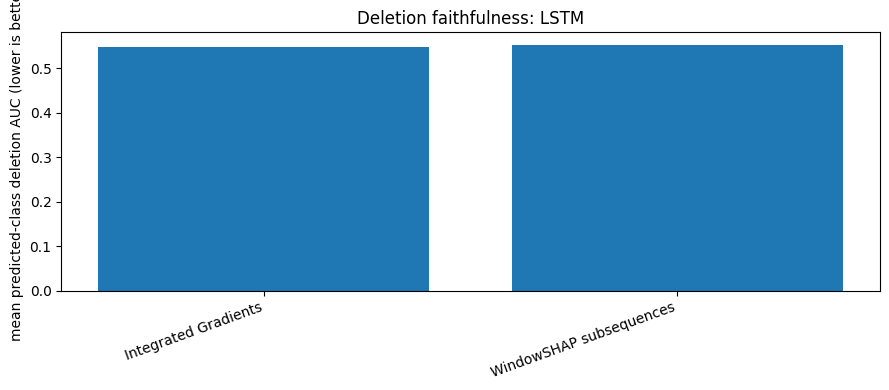

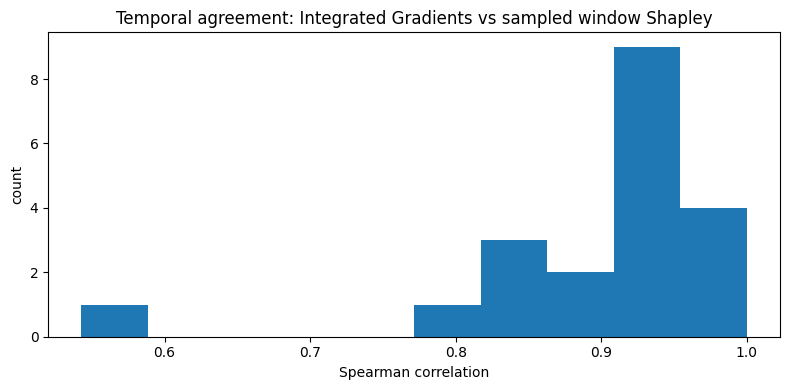

In [18]:
# Visualize the aggregate objective evaluation.
plt.figure(figsize=(9, 4))
deletion_plot = (
    xai_deletion
    .groupby("method", as_index=False)["deletion_auc"]
    .mean()
)
plt.bar(deletion_plot["method"], deletion_plot["deletion_auc"])
plt.ylabel("mean predicted-class deletion AUC (lower is better)")
plt.title(f"Deletion faithfulness: {evaluation_model_name}")
plt.xticks(rotation=20, ha="right")
save_plot(output_dir / "xai_deletion_faithfulness_summary.png")

plt.figure(figsize=(8, 4))
plt.hist(
    xai_agreement["ig_window_vs_window_shap_spearman"].dropna(),
    bins=10,
)
plt.xlabel("Spearman correlation")
plt.ylabel("count")
plt.title("Temporal agreement: Integrated Gradients vs sampled window Shapley")
save_plot(output_dir / "xai_cross_method_agreement.png")


## 11. Univariate volatility model for official C-SHAP

Epoch 01 | train=0.9139 | val=0.9576
Epoch 02 | train=0.7264 | val=1.0727
Epoch 03 | train=0.7442 | val=0.9512
Epoch 04 | train=0.7292 | val=0.9874
Epoch 05 | train=0.7081 | val=0.9597
Epoch 06 | train=0.7196 | val=1.0547
Epoch 07 | train=0.7146 | val=0.9817
Epoch 08 | train=0.7097 | val=0.9606
threshold: 0.590
balanced accuracy: 0.712
[[665 137]
 [ 66  97]]


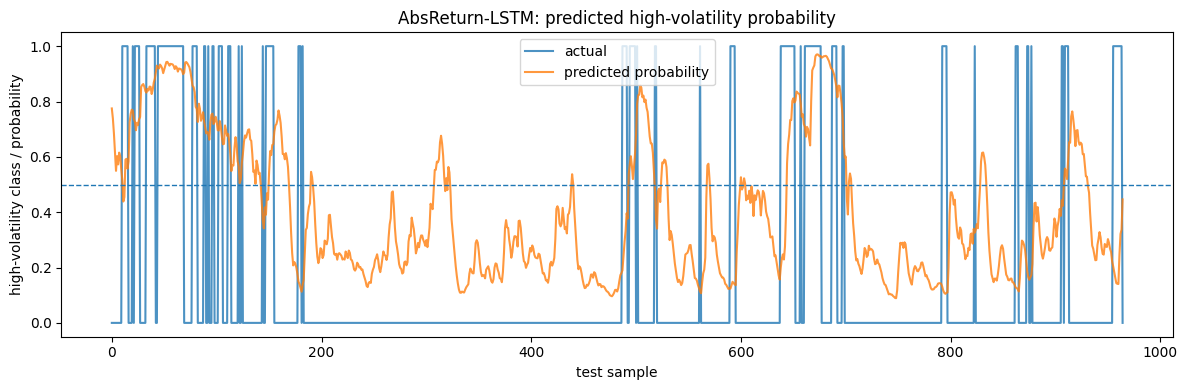

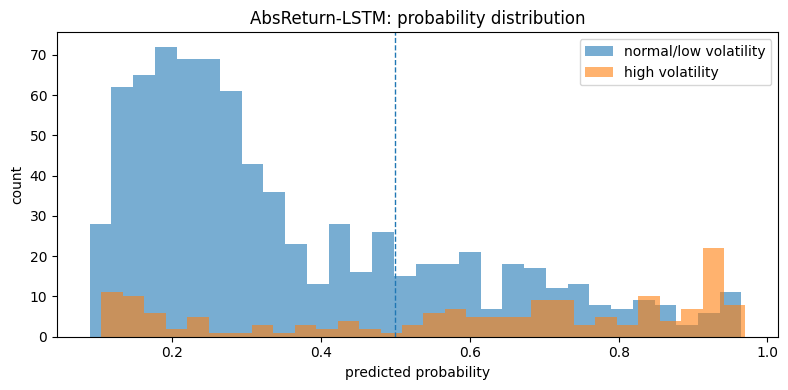

In [19]:
cshap_lstm = LSTMModel(n_features=1)

cshap_lstm = train_model(
    cshap_lstm,
    train_loader_uni,
    val_loader_uni,
    cfg,
)

val_probs_uni, val_labels_uni = predict_proba(cshap_lstm, val_loader_uni)
threshold_cshap = tune_threshold(val_labels_uni, val_probs_uni)

cshap_metrics = evaluate_model(cshap_lstm, test_loader_uni, threshold_cshap)

print(f"threshold: {threshold_cshap:.3f}")
print(f"balanced accuracy: {cshap_metrics['balanced_accuracy']:.3f}")
print(cshap_metrics["confusion_matrix"])

plot_probability_series(
    cshap_metrics["labels"],
    cshap_metrics["probs"],
    "AbsReturn-LSTM: predicted high-volatility probability",
    output_dir / "AbsReturn_LSTM_probability_series.png",
)

plot_probability_histogram(
    cshap_metrics["labels"],
    cshap_metrics["probs"],
    "AbsReturn-LSTM: probability distribution",
    output_dir / "AbsReturn_LSTM_probability_histogram.png",
)

In [20]:
val_preds_uni = (val_probs_uni >= threshold_cshap).astype(int)

val_metrics_uni = {
    "precision": precision_score(val_labels_uni, val_preds_uni, zero_division=0),
    "recall": recall_score(val_labels_uni, val_preds_uni, zero_division=0),
    "f1": f1_score(val_labels_uni, val_preds_uni, zero_division=0),
    "auc": roc_auc_score(val_labels_uni, val_probs_uni),
}

print(pd.Series(val_metrics_uni))

precision    0.504831
recall       0.728223
f1           0.596291
auc          0.752093
dtype: float64


## 12. Official C-SHAP

In [21]:
background_uni, _ = dataset_to_numpy(train_ds_uni, cfg.cshap_background)
x_cshap, y_cshap = dataset_to_numpy(test_ds_uni, cfg.cshap_explain)

t_cshap = np.linspace(0, cfg.lookback + 1, cfg.lookback)
decomposition = CustomDecomposition(
    "trend+bias+scale*(low_freq+var*high_freq)",
    noise_sigma=1,
    var_window_size=5,
)

# Official C-SHAP is applied to the raw model logit, not the sigmoid probability.
# Positive values increase evidence for a high-volatility regime.
# Negative values decrease evidence for a high-volatility regime.
cshap_logit_model = cshap_lstm.to(device)
cshap_logit_model.eval()

cshap = CSHAP(
    t=t_cshap,
    background_data=background_uni,
    decomposition=decomposition,
    softmax=False,
)

cshap_values, cshap_base_values = cshap.shap_values(
    t=t_cshap,
    x_samples=x_cshap,
    model=cshap_logit_model,
    device=device,
    exact=cfg.cshap_exact,
)

mean_values = cshap_values.mean(axis=0).squeeze()
mean_abs_values = np.abs(cshap_values).mean(axis=0).squeeze()

cshap_summary = pd.DataFrame({
    "component": decomposition.component_names,
    "mean_cshap_logit_value": mean_values,
    "mean_abs_cshap_logit_value": mean_abs_values,
}).sort_values("mean_abs_cshap_logit_value", ascending=False)

cshap_summary.to_csv(output_dir / "AbsReturn_LSTM_official_cshap_logit_summary.csv", index=False)
cshap_summary

,component,mean_cshap_logit_value,mean_abs_cshap_logit_value
1,bias,-0.869335,0.891413
0,trend,-0.094670,0.864804
3,low_freq,0.070118,0.127681
5,high_freq,0.004755,0.026799
2,scale,-0.012197,0.022858
4,var,0.003995,0.010502


### Global C-SHAP importance

This plot summarizes the average absolute contribution of each decomposition component across the explained test samples. Since C-SHAP is applied to the raw logit, larger values mean a stronger average influence on the model's evidence for a high-volatility regime.


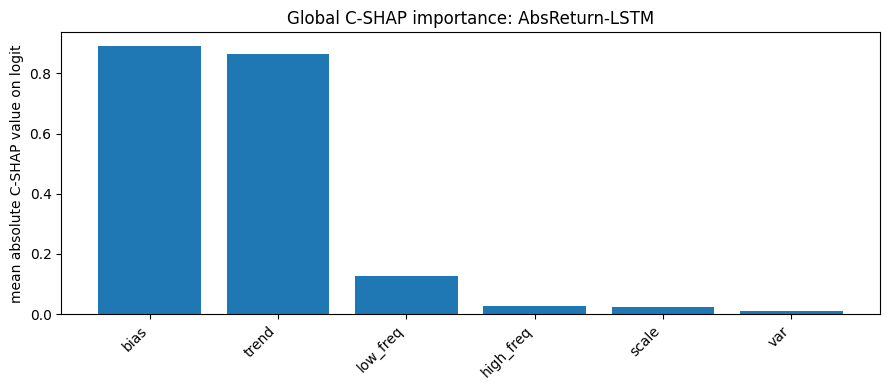

In [22]:
plot_bar(
    dict(zip(cshap_summary["component"], cshap_summary["mean_abs_cshap_logit_value"])),
    "Global C-SHAP importance: AbsReturn-LSTM",
    "mean absolute C-SHAP value on logit",
    output_dir / "AbsReturn_LSTM_global_cshap_logit_importance.png",
)

### Objective evaluation of C-SHAP

C-SHAP is evaluated separately because it explains decomposed temporal components rather than features or temporal windows. Three compatible criteria are used:

1. **Completeness:** whether the component attributions reconstruct the difference between the prediction logit and the C-SHAP base logit.
2. **Deletion faithfulness:** how rapidly the model logit changes when the most important signal components are neutralized.
3. **Stability:** whether small perturbations of the input preserve the ranking of component importance.

Direct agreement with Integrated Gradients or WindowSHAP is not calculated because these methods operate in different explanation spaces.


In [23]:
def cshap_completeness_table(
    shap_values: np.ndarray,
    base_values: np.ndarray,
    prediction_logits: np.ndarray,
) -> pd.DataFrame:
    """Calculate local-accuracy residuals for C-SHAP in logit space."""
    shap_values = np.asarray(shap_values)
    base_values = np.asarray(base_values).squeeze()
    prediction_logits = np.asarray(prediction_logits).reshape(-1)

    if base_values.ndim == 0:
        base_values = np.repeat(float(base_values), len(prediction_logits))
    else:
        base_values = base_values.reshape(-1)

    shap_sums = shap_values.reshape(len(prediction_logits), -1).sum(axis=1)
    reconstructed = base_values + shap_sums
    residuals = np.abs(prediction_logits - reconstructed)

    return pd.DataFrame({
        "prediction_logit": prediction_logits,
        "base_logit": base_values,
        "sum_cshap_values": shap_sums,
        "reconstructed_logit": reconstructed,
        "absolute_residual": residuals,
    })


def reconstruct_cshap_signal(
    component_matrix: np.ndarray,
    component_names: list[str],
) -> np.ndarray:
    """Reconstruct the signal for the decomposition used in this notebook.

    The configured expression is:
        trend + bias + scale * (low_freq + var * high_freq)
    """
    components = {
        name: np.asarray(component_matrix)[:, i]
        for i, name in enumerate(component_names)
    }

    required = {"trend", "bias", "scale", "low_freq", "var", "high_freq"}
    missing = required.difference(components)
    if missing:
        raise ValueError(
            "The C-SHAP deletion evaluator expects components "
            f"{sorted(required)}, but these were missing: {sorted(missing)}"
        )

    return (
        components["trend"]
        + components["bias"]
        + components["scale"]
        * (
            components["low_freq"]
            + components["var"] * components["high_freq"]
        )
    )


def neutralize_cshap_component(
    component_matrix: np.ndarray,
    component_names: list[str],
    component_name: str,
) -> np.ndarray:
    """Neutralize one component while preserving the decomposition structure."""
    modified = np.asarray(component_matrix, dtype=float).copy()
    idx = component_names.index(component_name)

    # Additive components are neutral at zero. Multiplicative components are
    # neutral at one so that they stop scaling the remaining signal.
    neutral_value = 1.0 if component_name in {"scale", "var"} else 0.0
    modified[:, idx] = neutral_value
    return modified


def cshap_deletion_curve(
    model: nn.Module,
    signal: np.ndarray,
    shap_values: np.ndarray,
    decomposition,
    t: np.ndarray,
    device: torch.device,
) -> pd.DataFrame:
    """Neutralize C-SHAP components from most to least important."""
    signal = np.asarray(signal).reshape(-1)
    shap_values = np.asarray(shap_values).reshape(-1)
    names = list(decomposition.component_names)

    components = decomposition.decompose(
        t,
        signal.reshape(1, -1, 1),
    )[0]

    reconstructed = reconstruct_cshap_signal(components, names)
    reconstruction_mae = float(np.mean(np.abs(signal - reconstructed)))

    order = np.argsort(np.abs(shap_values))[::-1]
    current_components = np.asarray(components, dtype=float).copy()
    rows = []

    def model_logit(reconstructed_signal: np.ndarray) -> float:
        tensor = torch.tensor(
            reconstructed_signal.reshape(1, -1, 1),
            dtype=torch.float32,
            device=device,
        )
        with torch.no_grad():
            return float(model(tensor).cpu().item())

    rows.append({
        "components_removed": 0,
        "fraction_removed": 0.0,
        "removed_component": "none",
        "logit": model_logit(reconstructed),
        "reconstruction_mae": reconstruction_mae,
    })

    for step, component_idx in enumerate(order, start=1):
        component_name = names[int(component_idx)]
        current_components = neutralize_cshap_component(
            current_components,
            names,
            component_name,
        )
        modified_signal = reconstruct_cshap_signal(
            current_components,
            names,
        )
        rows.append({
            "components_removed": step,
            "fraction_removed": step / len(names),
            "removed_component": component_name,
            "logit": model_logit(modified_signal),
            "reconstruction_mae": reconstruction_mae,
        })

    return pd.DataFrame(rows)


def cshap_deletion_auc(curve: pd.DataFrame) -> float:
    """Area under the original-class evidence deletion curve.

    Logits are oriented toward the class predicted before deletion. A lower
    area means that neutralising highly ranked components removes evidence for
    that class more rapidly.
    """
    original_logit = float(curve["logit"].iloc[0])
    direction = 1.0 if original_logit >= 0.0 else -1.0
    oriented_evidence = direction * curve["logit"].to_numpy()
    denominator = abs(original_logit) + 1e-12
    normalized_remaining = oriented_evidence / denominator

    return float(np.trapz(
        normalized_remaining,
        curve["fraction_removed"].to_numpy(),
    ))


def cshap_rank_stability(
    samples: np.ndarray,
    reference_values: np.ndarray,
    model: nn.Module,
    cshap_class,
    decomposition,
    background_data: np.ndarray,
    t: np.ndarray,
    device: torch.device,
    exact: bool,
    repeats: int,
    noise_std: float,
) -> pd.DataFrame:
    """Measure component-ranking stability under small Gaussian perturbations."""
    samples = np.asarray(samples)
    reference_values = np.asarray(reference_values)
    rows = []

    for sample_idx in range(len(samples)):
        reference_importance = np.abs(
            reference_values[sample_idx].reshape(-1)
        )

        for repeat in range(repeats):
            noisy = samples[sample_idx:sample_idx + 1].copy()
            noisy += np.random.normal(
                loc=0.0,
                scale=noise_std,
                size=noisy.shape,
            )

            explainer = cshap_class(
                t=t,
                background_data=background_data,
                decomposition=decomposition,
                softmax=False,
            )
            noisy_values, _ = explainer.shap_values(
                t=t,
                x_samples=noisy,
                model=model,
                device=device,
                exact=exact,
            )
            noisy_importance = np.abs(
                np.asarray(noisy_values).reshape(-1)
            )

            correlation = pd.Series(reference_importance).corr(
                pd.Series(noisy_importance),
                method="spearman",
            )

            rows.append({
                "sample_idx": sample_idx,
                "repeat": repeat,
                "spearman": correlation,
            })

    return pd.DataFrame(rows)


# Use a deterministic subset of the already explained test observations.
n_cshap_eval = min(cfg.cshap_eval_samples, len(x_cshap))
cshap_eval_indices = np.linspace(
    0,
    len(x_cshap) - 1,
    n_cshap_eval,
    dtype=int,
)

x_cshap_eval = x_cshap[cshap_eval_indices]
cshap_values_eval = cshap_values[cshap_eval_indices]

base_array_all = np.asarray(cshap_base_values).squeeze()
if base_array_all.ndim == 0:
    cshap_base_eval = np.repeat(
        float(base_array_all),
        n_cshap_eval,
    )
else:
    cshap_base_eval = base_array_all[cshap_eval_indices]

cshap_logits_eval = []
for sample in x_cshap_eval:
    tensor = torch.tensor(
        sample.reshape(1, cfg.lookback, 1),
        dtype=torch.float32,
        device=device,
    )
    with torch.no_grad():
        cshap_logits_eval.append(
            float(cshap_logit_model(tensor).cpu().item())
        )
cshap_logits_eval = np.asarray(cshap_logits_eval)

# 1. Completeness.
cshap_completeness = cshap_completeness_table(
    cshap_values_eval,
    cshap_base_eval,
    cshap_logits_eval,
)
cshap_completeness.insert(
    0,
    "sample_idx",
    cshap_eval_indices,
)

# 2. Component-deletion faithfulness.
cshap_deletion_curves = []
cshap_deletion_summary_rows = []

for local_idx, original_idx in enumerate(cshap_eval_indices):
    curve = cshap_deletion_curve(
        model=cshap_logit_model,
        signal=x_cshap_eval[local_idx, :, 0],
        shap_values=cshap_values_eval[local_idx],
        decomposition=decomposition,
        t=t_cshap,
        device=device,
    )
    curve.insert(0, "sample_idx", int(original_idx))
    cshap_deletion_curves.append(curve)

    cshap_deletion_summary_rows.append({
        "sample_idx": int(original_idx),
        "deletion_auc": cshap_deletion_auc(curve),
        "reconstruction_mae": float(
            curve["reconstruction_mae"].iloc[0]
        ),
    })

cshap_deletion_curves = pd.concat(
    cshap_deletion_curves,
    ignore_index=True,
)
cshap_deletion_summary = pd.DataFrame(
    cshap_deletion_summary_rows
)

# 3. Stability. To control runtime, evaluate up to five representative samples.
n_stability_samples = min(5, n_cshap_eval)
stability_positions = np.linspace(
    0,
    n_cshap_eval - 1,
    n_stability_samples,
    dtype=int,
)
cshap_stability = cshap_rank_stability(
    samples=x_cshap_eval[stability_positions],
    reference_values=cshap_values_eval[stability_positions],
    model=cshap_logit_model,
    cshap_class=CSHAP,
    decomposition=decomposition,
    background_data=background_uni,
    t=t_cshap,
    device=device,
    exact=cfg.cshap_exact,
    repeats=cfg.cshap_stability_repeats,
    noise_std=cfg.cshap_stability_noise_std,
)

cshap_objective_summary = pd.DataFrame({
    "criterion": [
        "C-SHAP mean absolute completeness residual",
        "C-SHAP mean component-deletion AUC",
        "C-SHAP mean component-ranking stability",
        "C-SHAP mean decomposition reconstruction MAE",
    ],
    "value": [
        cshap_completeness["absolute_residual"].mean(),
        cshap_deletion_summary["deletion_auc"].mean(),
        cshap_stability["spearman"].mean(),
        cshap_deletion_summary["reconstruction_mae"].mean(),
    ],
})

cshap_completeness.to_csv(
    output_dir / "cshap_completeness_diagnostics.csv",
    index=False,
)
cshap_deletion_curves.to_csv(
    output_dir / "cshap_component_deletion_curves.csv",
    index=False,
)
cshap_deletion_summary.to_csv(
    output_dir / "cshap_component_deletion_summary.csv",
    index=False,
)
cshap_stability.to_csv(
    output_dir / "cshap_component_stability.csv",
    index=False,
)
cshap_objective_summary.to_csv(
    output_dir / "cshap_objective_evaluation_summary.csv",
    index=False,
)

cshap_objective_summary


C:\Users\justu\AppData\Local\Temp\ipykernel_41152\971509807.py:155: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\971509807.py:155: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\971509807.py:155: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\971509807.py:155: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(
C:\Users\justu\AppData\Local\Temp\ipykernel_41152\971509807.py:155: DeprecationWarni

,criterion,value
0,C-SHAP mean absolute completeness residual,4.582107e-08
1,C-SHAP mean component-deletion AUC,4.315576e-01
2,C-SHAP mean component-ranking stability,9.862857e-01
3,C-SHAP mean decomposition reconstruction MAE,3.869590e-17


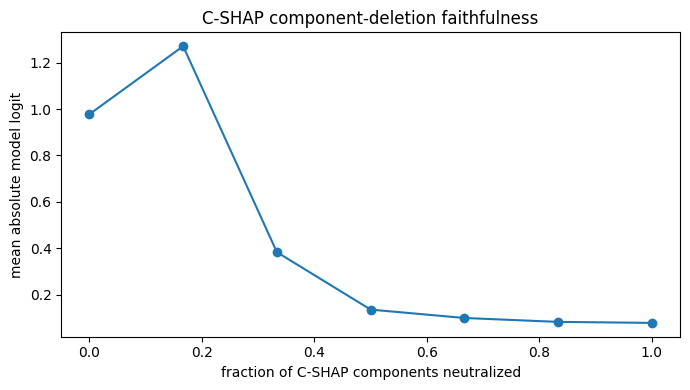

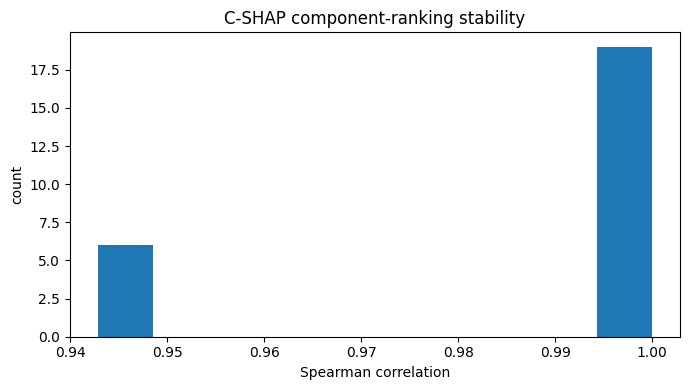

In [24]:
# Plot the C-SHAP objective evaluation.
mean_curve = (
    cshap_deletion_curves
    .groupby("fraction_removed", as_index=False)
    .agg(mean_abs_logit=("logit", lambda values: np.abs(values).mean()))
)

plt.figure(figsize=(7, 4))
plt.plot(
    mean_curve["fraction_removed"],
    mean_curve["mean_abs_logit"],
    marker="o",
)
plt.xlabel("fraction of C-SHAP components neutralized")
plt.ylabel("mean absolute model logit")
plt.title("C-SHAP component-deletion faithfulness")
save_plot(output_dir / "cshap_component_deletion_faithfulness.png")

plt.figure(figsize=(7, 4))
plt.hist(
    cshap_stability["spearman"].dropna(),
    bins=10,
)
plt.xlabel("Spearman correlation")
plt.ylabel("count")
plt.title("C-SHAP component-ranking stability")
save_plot(output_dir / "cshap_component_stability.png")

## 13. Instance-level C-SHAP visualization

In [25]:
def colored_line(ax, x, y, values, cmap="coolwarm"):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    bound = np.max(np.abs(values)) + 1e-12
    norm = Normalize(vmin=-bound, vmax=bound)

    line = LineCollection(segments, cmap=cmap, norm=norm)
    line.set_array(values[:-1])
    line.set_linewidth(2)

    ax.add_collection(line)
    ax.scatter(x, y, c=values, cmap=cmap, norm=norm, s=18, zorder=3)
    ax.set_xlim(x.min(), x.max())

    y_range = np.ptp(y) or 1.0
    ax.set_ylim(y.min() - 0.1 * y_range, y.max() + 0.1 * y_range)

    return line


def distribute_cshap_over_time(components, shap_values):
    components = np.asarray(components)
    shap_values = np.asarray(shap_values).reshape(-1)

    n_time, n_components = components.shape
    attribution = np.zeros(n_time)

    for j in range(n_components):
        weights = np.abs(components[:, j])
        weights = weights / (weights.sum() + 1e-12)
        attribution += shap_values[j] * weights * n_time

    return attribution


def plot_cshap_instance(signal, decomposition, shap_values, base_logit, prediction_logit, prediction_prob, t, title, path=None):
    signal = np.asarray(signal).reshape(-1)
    shap_values = np.asarray(shap_values).squeeze()

    components = decomposition.decompose(t, signal.reshape(1, -1, 1))[0]
    time_attr = distribute_cshap_over_time(components, shap_values)

    fig = plt.figure(figsize=(16, 8))
    grid = fig.add_gridspec(
        nrows=7,
        ncols=3,
        width_ratios=[1.25, 0.55, 1.0],
        wspace=0.35,
        hspace=0.15,
    )

    fig.suptitle(title, fontsize=22)

    x_axis = np.arange(len(signal))

    ax_signal = fig.add_subplot(grid[2:5, 0])
    line = colored_line(ax_signal, x_axis, signal, time_attr)
    ax_signal.set_title("C-SHAP explanation")
    ax_signal.set_xlabel("time step")
    ax_signal.set_ylabel("standardized abs_return")
    fig.colorbar(line, ax=ax_signal, fraction=0.046, pad=0.04).set_label("visualized logit attribution")

    ax_original = fig.add_subplot(grid[0, 2])
    ax_original.plot(x_axis, signal)
    ax_original.set_title("signal decomposition")
    ax_original.set_xticks([])
    ax_original.yaxis.tick_right()

    limit = np.max(np.abs(shap_values)) + 1e-12

    for i, name in enumerate(decomposition.component_names):
        row = i + 1
        val = float(shap_values[i])

        ax_bar = fig.add_subplot(grid[row, 1])
        ax_bar.barh([0], [val], color="tab:red" if val >= 0 else "tab:blue")
        ax_bar.axvline(0, color="black", linewidth=0.8)
        ax_bar.set_xlim(-1.25 * limit, 1.25 * limit)
        ax_bar.set_yticks([])
        ax_bar.set_xticks([])
        ax_bar.set_ylabel(name, rotation=90, labelpad=18)
        ax_bar.text(
            val + np.sign(val if val != 0 else 1) * limit * 0.07,
            0,
            f"{val:+.6f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9,
        )

        ax_component = fig.add_subplot(grid[row, 2])
        ax_component.plot(x_axis, components[:, i])
        ax_component.set_xticks([])
        ax_component.yaxis.tick_right()

        if i == len(decomposition.component_names) - 1:
            ax_component.set_xlabel("time step")
            ax_component.set_xticks(np.linspace(0, len(signal) - 1, 5, dtype=int))

    fig.text(
        0.52,
        0.80,
        f"base logit\n= {float(np.asarray(base_logit).squeeze()):.3f}",
        ha="center",
        va="center",
        fontsize=12,
    )
    fig.text(
        0.52,
        0.12,
        f"prediction logit\n= {prediction_logit:.3f}\nP(high vol) = {prediction_prob:.3f}",
        ha="center",
        va="center",
        fontsize=12,
    )

    if path is not None:
        plt.savefig(path, dpi=200, bbox_inches="tight")

    plt.show()
    return fig

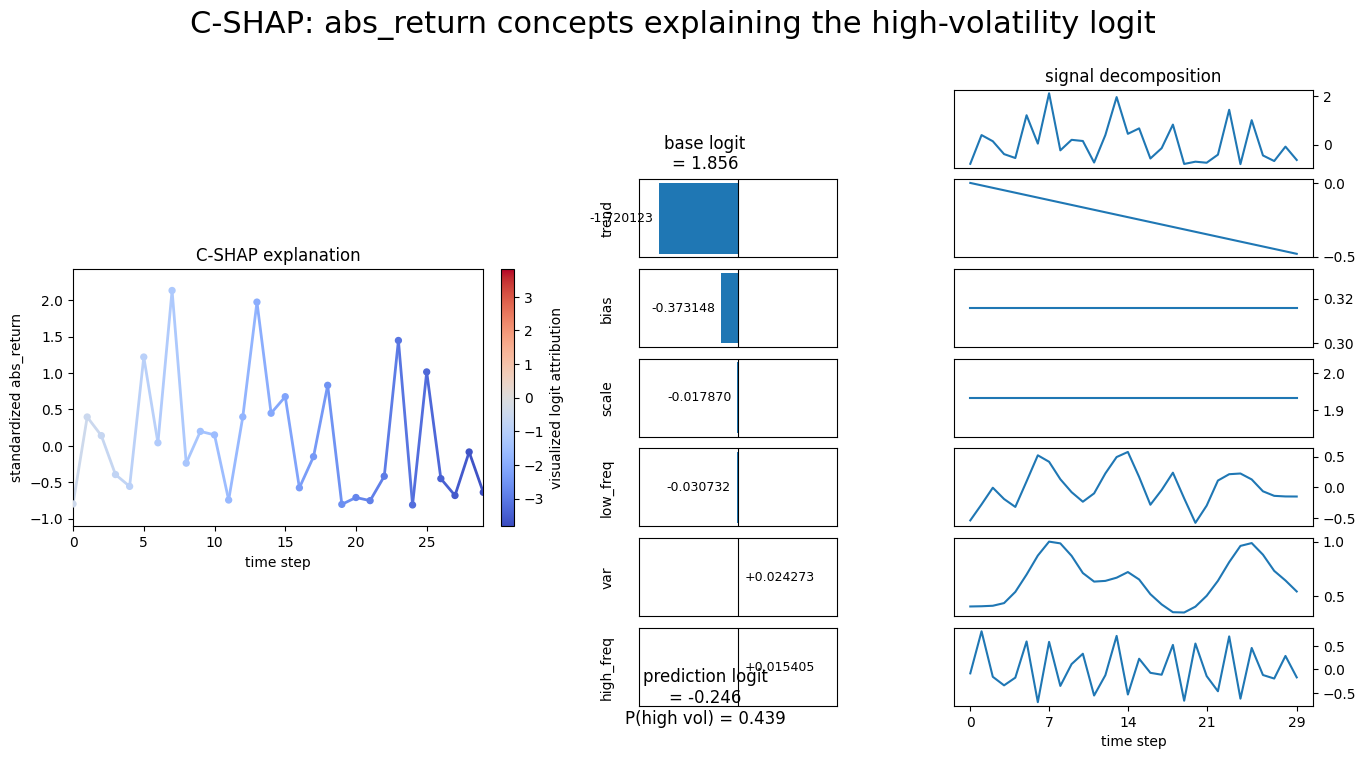

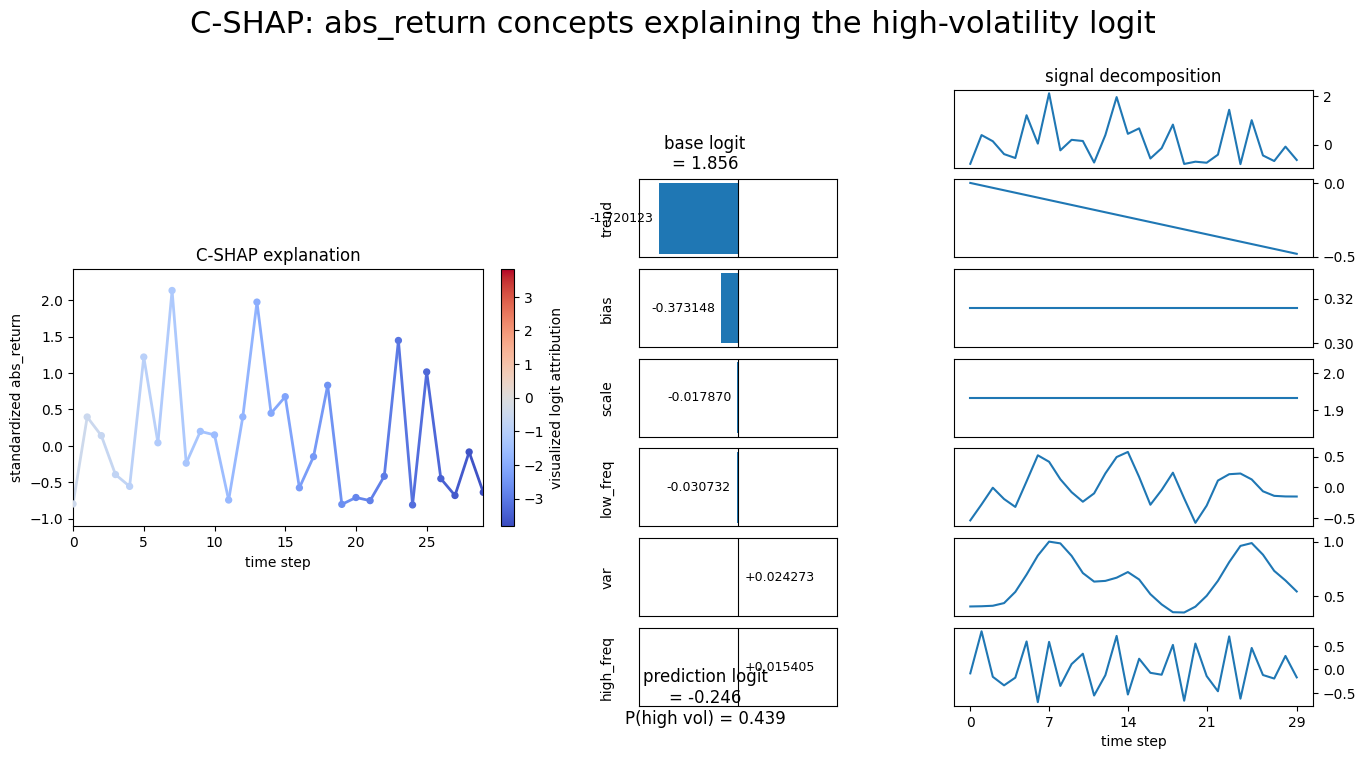

In [26]:
pred_logits = []
pred_probs = []

for i in range(len(x_cshap)):
    x_tensor = torch.tensor(x_cshap[i:i + 1], dtype=torch.float32, device=device)
    with torch.no_grad():
        logit = cshap_logit_model(x_tensor).cpu().item()
        prob = torch.sigmoid(torch.tensor(logit)).item()

    pred_logits.append(logit)
    pred_probs.append(prob)

pred_logits = np.array(pred_logits)
pred_probs = np.array(pred_probs)

base_array = np.asarray(cshap_base_values).squeeze()
if base_array.ndim == 0:
    differences = np.abs(pred_logits - float(base_array))
else:
    differences = np.abs(pred_logits - base_array)

instance_id = int(np.argmax(differences))

base_logit = float(base_array if base_array.ndim == 0 else base_array[instance_id])
prediction_logit = float(pred_logits[instance_id])
prediction_prob = float(pred_probs[instance_id])

plot_cshap_instance(
    signal=x_cshap[instance_id, :, 0],
    decomposition=decomposition,
    shap_values=cshap_values[instance_id].squeeze(),
    base_logit=base_logit,
    prediction_logit=prediction_logit,
    prediction_prob=prediction_prob,
    t=t_cshap,
    title="C-SHAP: abs_return concepts explaining the high-volatility logit",
    path=output_dir / "AbsReturn_LSTM_CSHAP_logit_instance.png",
)

## 14. TP, FP, TN, and FN C-SHAP cases

In [27]:
def prediction_table(model: nn.Module, dataset: Dataset, threshold: float) -> pd.DataFrame:
    rows = []

    model.eval()
    for idx in range(len(dataset)):
        x, y = dataset[idx]
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).cpu().item()

        rows.append({
            "idx": idx,
            "y_true": int(y.item()),
            "prob": prob,
            "y_pred": int(prob >= threshold),
            "confidence": abs(prob - 0.5),
        })

    return pd.DataFrame(rows)


def select_cases(preds: pd.DataFrame):
    conditions = {
        "TP": (preds["y_true"] == 1) & (preds["y_pred"] == 1),
        "FP": (preds["y_true"] == 0) & (preds["y_pred"] == 1),
        "TN": (preds["y_true"] == 0) & (preds["y_pred"] == 0),
        "FN": (preds["y_true"] == 1) & (preds["y_pred"] == 0),
    }

    selected = {}
    for name, condition in conditions.items():
        subset = preds[condition]
        if subset.empty:
            selected[name] = None
        else:
            selected[name] = subset.sort_values("confidence", ascending=False).iloc[0]

    return selected


preds_uni = prediction_table(cshap_lstm, test_ds_uni, threshold_cshap)
selected_cases = select_cases(preds_uni)

for name, row in selected_cases.items():
    if row is None:
        print(f"{name}: no case found")
    else:
        print(f"{name}: idx={int(row['idx'])}, true={int(row['y_true'])}, pred={int(row['y_pred'])}, prob={row['prob']:.3f}")

TP: idx=673, true=1, pred=1, prob=0.970
FP: idx=681, true=0, pred=1, prob=0.965
TN: idx=748, true=0, pred=0, prob=0.089
FN: idx=795, true=1, pred=0, prob=0.105


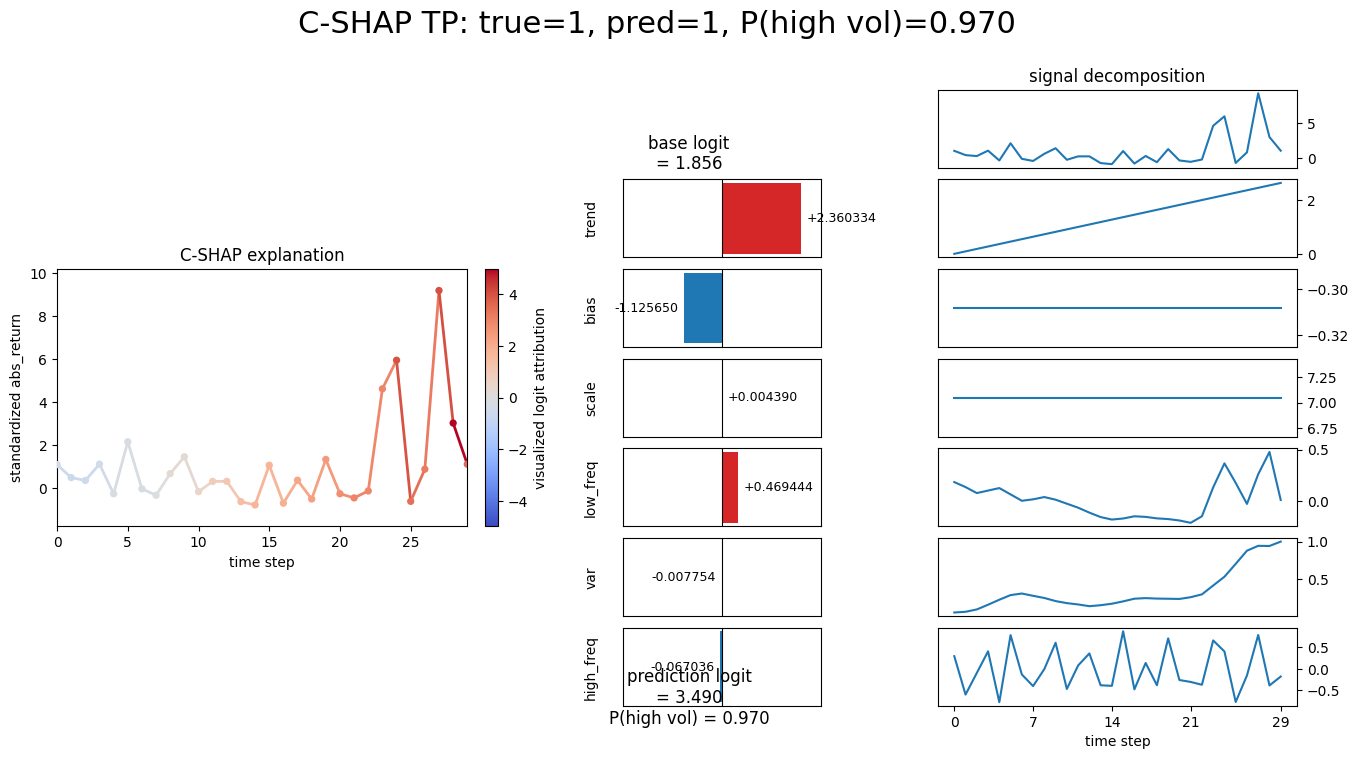

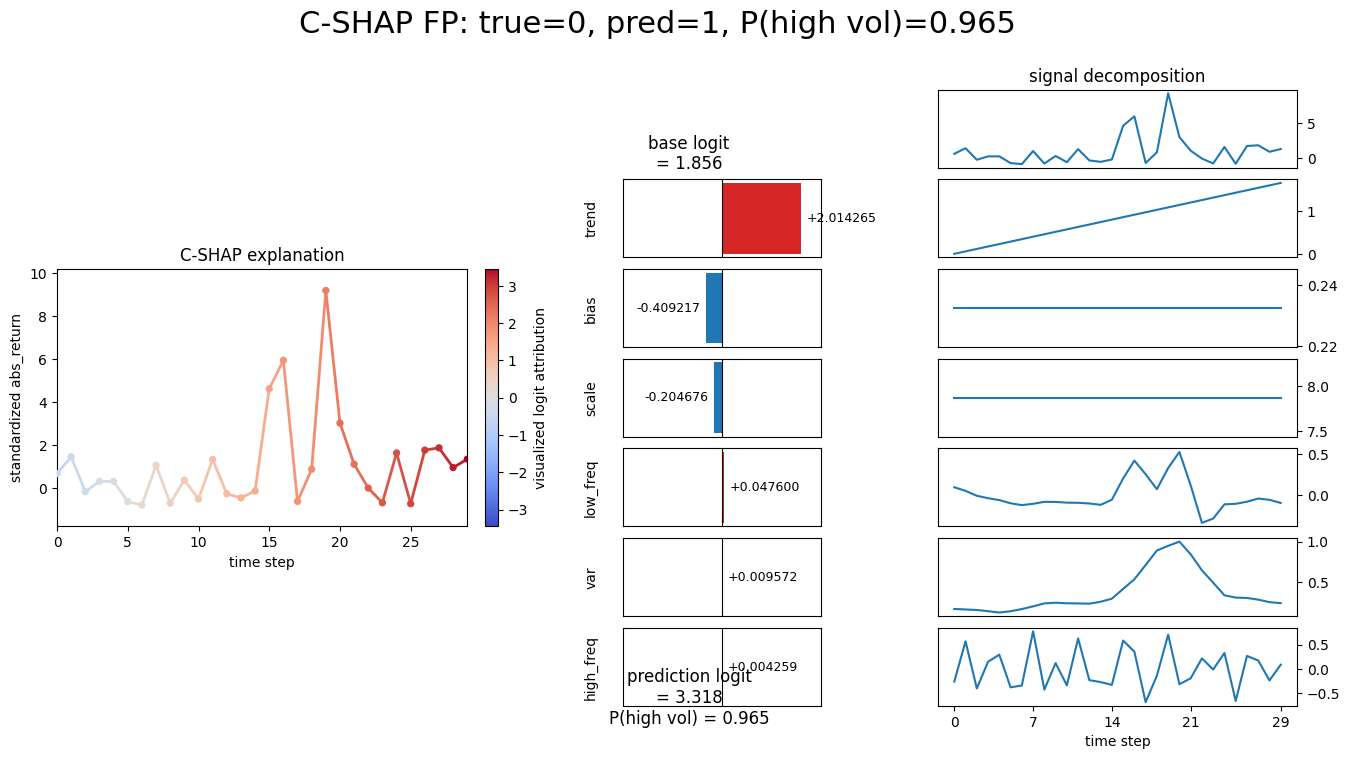

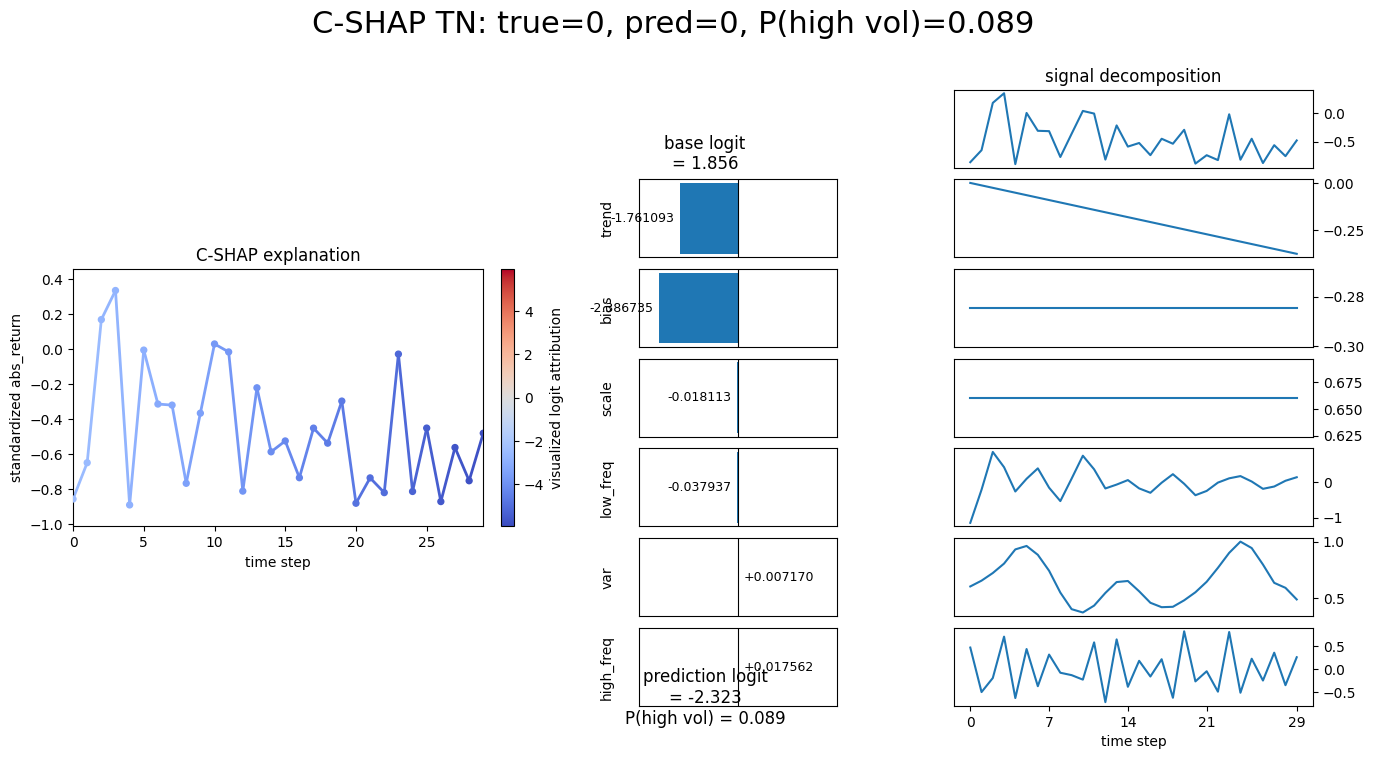

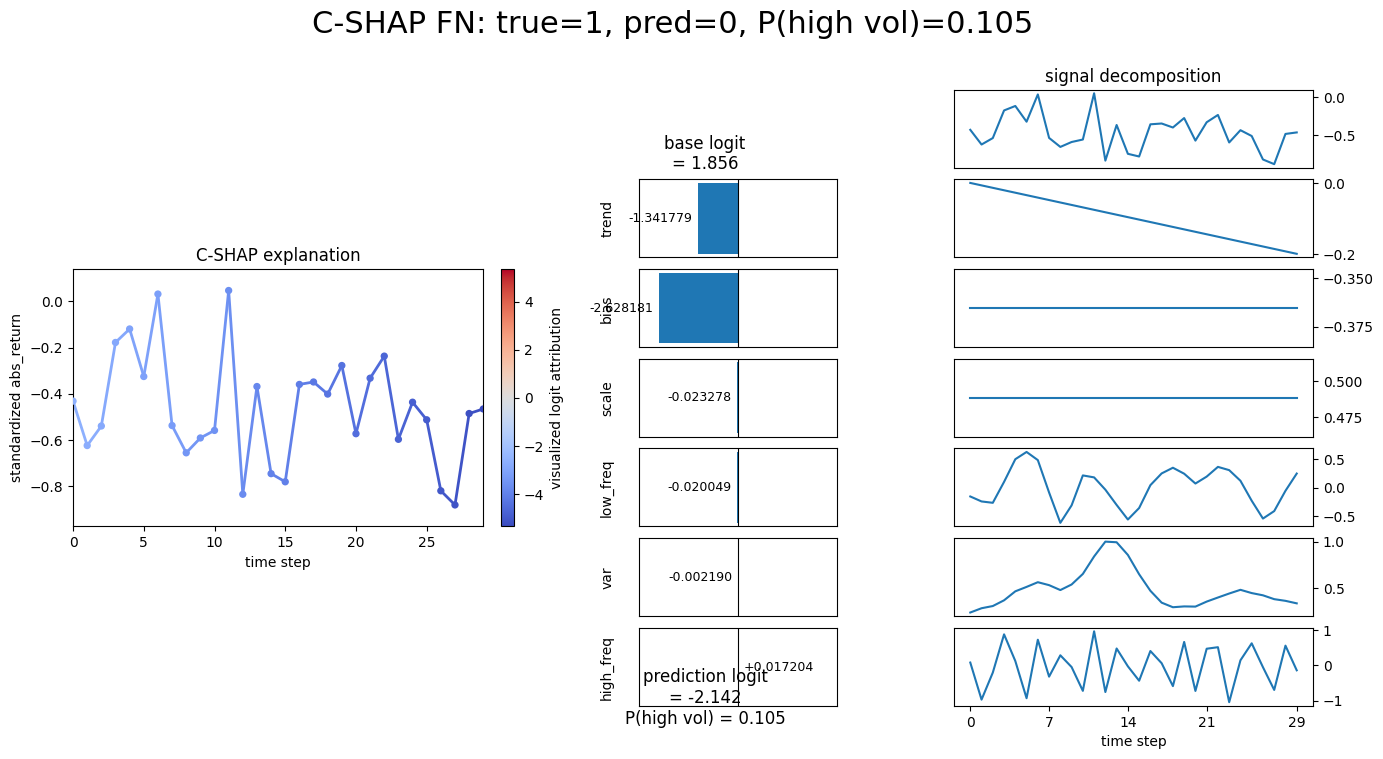

,case,idx,y_true,y_pred,prob,logit,base_logit,cshap_logit_trend,cshap_logit_bias,cshap_logit_scale,cshap_logit_low_freq,cshap_logit_var,cshap_logit_high_freq
0,TP,673,1,1,0.970391,3.489618,1.85589,2.360334,-1.125650,0.004390,0.469444,-0.007754,-0.067036
1,FP,681,0,1,0.965031,3.317693,1.85589,2.014265,-0.409217,-0.204676,0.047600,0.009572,0.004259
2,TN,748,0,0,0.089215,-2.323256,1.85589,-1.761093,-2.386735,-0.018113,-0.037937,0.007170,0.017562
3,FN,795,1,0,0.105045,-2.142382,1.85589,-1.341779,-2.628181,-0.023278,-0.020049,-0.002190,0.017204


In [28]:
case_samples = []
case_meta = []

for case_name, row in selected_cases.items():
    if row is None:
        continue

    x, _ = test_ds_uni[int(row["idx"])]
    case_samples.append(x.numpy())
    case_meta.append({
        "case": case_name,
        "idx": int(row["idx"]),
        "y_true": int(row["y_true"]),
        "y_pred": int(row["y_pred"]),
        "prob": float(row["prob"]),
    })

x_cases = np.stack(case_samples)

case_cshap = CSHAP(
    t=t_cshap,
    background_data=background_uni,
    decomposition=decomposition,
    softmax=False,
)

case_shap_values, case_base_values = case_cshap.shap_values(
    t=t_cshap,
    x_samples=x_cases,
    model=cshap_logit_model,
    device=device,
    exact=cfg.cshap_exact,
)

rows = []

for i, meta in enumerate(case_meta):
    base_vals = np.asarray(case_base_values).squeeze()
    base_logit = float(base_vals if base_vals.ndim == 0 else base_vals[i])
    shap_vals = case_shap_values[i].squeeze()

    x_tensor = torch.tensor(x_cases[i:i + 1], dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_logit = cshap_logit_model(x_tensor).cpu().item()
        pred_prob = torch.sigmoid(torch.tensor(pred_logit)).item()

    row = {
        "case": meta["case"],
        "idx": meta["idx"],
        "y_true": meta["y_true"],
        "y_pred": meta["y_pred"],
        "prob": pred_prob,
        "logit": pred_logit,
        "base_logit": base_logit,
    }

    for component, value in zip(decomposition.component_names, shap_vals):
        row[f"cshap_logit_{component}"] = value

    rows.append(row)

    title = (
        f"C-SHAP {meta['case']}: "
        f"true={meta['y_true']}, pred={meta['y_pred']}, P(high vol)={pred_prob:.3f}"
    )

    plot_cshap_instance(
        signal=x_cases[i, :, 0],
        decomposition=decomposition,
        shap_values=shap_vals,
        base_logit=base_logit,
        prediction_logit=pred_logit,
        prediction_prob=pred_prob,
        t=t_cshap,
        title=title,
        path=output_dir / f"AbsReturn_LSTM_CSHAP_logit_{meta['case']}.png",
    )

case_summary = pd.DataFrame(rows)
case_summary.to_csv(output_dir / "AbsReturn_LSTM_CSHAP_logit_TP_FP_TN_FN.csv", index=False)
case_summary

### Reproducibility metadata

The following cell stores the full configuration and key package versions with the generated outputs.


In [29]:
package_names = [
    "numpy",
    "pandas",
    "yfinance",
    "scikit-learn",
    "torch",
    "captum",
    "matplotlib",
    "scipy",
    "shap",
    "PyWavelets",
    "emd",
]

package_versions = {}
for package_name in package_names:
    try:
        from importlib.metadata import version
        package_versions[package_name] = version(package_name)
    except Exception:
        package_versions[package_name] = "not available"

run_metadata = {
    "python_version": platform.python_version(),
    "device": str(device),
    "configuration": asdict(cfg),
    "package_versions": package_versions,
}

with (output_dir / "run_metadata.json").open("w", encoding="utf-8") as handle:
    json.dump(run_metadata, handle, indent=2)

run_metadata


{'python_version': '3.12.10',
 'device': 'cuda',
 'configuration': {'ticker': '^GSPC',
  'start_date': '2000-01-01',
  'end_date': '2026-06-22',
  'lookback': 30,
  'forecast_horizon': 5,
  'high_vol_quantile': 0.75,
  'batch_size': 64,
  'epochs': 30,
  'patience': 5,
  'learning_rate': 0.001,
  'train_ratio': 0.7,
  'val_ratio': 0.15,
  'seed': 42,
  'shap_samples': 300,
  'window_size': 5,
  'cshap_background': 20,
  'cshap_explain': 40,
  'cshap_exact': True,
  'cshap_eval_samples': 20,
  'cshap_stability_repeats': 5,
  'cshap_stability_noise_std': 0.03,
  'xai_eval_samples': 20,
  'xai_eval_permutations': 100,
  'xai_stability_samples': 5,
  'xai_stability_repeats': 10,
  'xai_noise_std': 0.03,
  'deletion_steps': 10,
  'output_dir': 'outputs'},
 'package_versions': {'numpy': '2.2.6',
  'pandas': '2.2.3',
  'yfinance': '1.0',
  'scikit-learn': '1.6.1',
  'torch': '2.5.1+cu121',
  'captum': '0.8.0',
  'matplotlib': '3.10.3',
  'scipy': '1.15.3',
  'shap': '0.46.0',
  'PyWavelets': 

## 15. Output files

In [30]:
sorted(output_dir.glob("*"))

[WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_CSHAP_logit_FN.png'),
 WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_CSHAP_logit_FP.png'),
 WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_CSHAP_logit_instance.png'),
 WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_CSHAP_logit_TN.png'),
 WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_CSHAP_logit_TP.png'),
 WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_CSHAP_logit_TP_FP_TN_FN.csv'),
 WindowsPath('C:/Users/justu/Downloads/CSHAP_for_time_series_extracted/CSHAP-for-time-series/outputs/AbsReturn_LSTM_global_cshap_logit_importance.png'),
 Win